In [2]:
import pandas as pd
df = pd.read_csv("raw_adipose_cvd.csv")

In [3]:
df.describe()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,lbxglu,lbdldl,CVD_Status
count,58830.000000,58830.000000,58830.000000,58830.000000,58830.000000,46722.000000,20756.000000,20060.000000,58830.000000
mean,66800.358032,33.861465,1.504759,25.706046,87.392019,119.495013,106.664483,108.563460,0.062706
std,20883.256084,23.747809,0.499982,7.701808,22.409746,18.731609,33.713170,35.556502,0.242436
min,31128.000000,2.000000,1.000000,11.500000,37.800000,66.000000,21.000000,9.000000,0.000000
25%,48714.250000,12.000000,1.000000,19.830000,71.500000,106.000000,92.000000,83.000000,0.000000
50%,66075.500000,30.000000,2.000000,25.000000,88.300000,116.000000,99.000000,105.000000,0.000000
75%,85162.750000,54.000000,2.000000,30.200000,102.800000,128.000000,108.000000,130.000000,0.000000
max,102956.000000,85.000000,2.000000,84.870000,179.000000,270.000000,584.000000,375.000000,1.000000


In [11]:
df.columns

Index(['SEQN', 'ridageyr', 'riagendr', 'bmxbmi', 'bmxwaist', 'bpxsy1',
       'lbxglu', 'lbdldl', 'CVD_Status'],
      dtype='str')

In [3]:
df.head()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,lbxglu,lbdldl,CVD_Status
0,31128.0,11.0,2.0,17.45,62.8,100.0,NaN,NaN,0
1,31129.0,15.0,1.0,26.53,97.8,104.0,NaN,NaN,0
2,31131.0,44.0,2.0,30.90,96.0,144.0,90.0,49.0,1
3,31132.0,70.0,1.0,24.74,96.5,138.0,157.0,75.0,0
4,31133.0,16.0,2.0,16.79,62.0,120.0,84.0,81.0,0


In [4]:
df = df.drop(columns=['lbxglu', 'lbdldl'])

In [5]:
df.head()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,CVD_Status
0,31128.0,11.0,2.0,17.45,62.8,100.0,0
1,31129.0,15.0,1.0,26.53,97.8,104.0,0
2,31131.0,44.0,2.0,30.90,96.0,144.0,1
3,31132.0,70.0,1.0,24.74,96.5,138.0,0
4,31133.0,16.0,2.0,16.79,62.0,120.0,0


In [12]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2_contingency

# 1. LOAD RAW DATA
df = pd.read_csv("raw_adipose_cvd.csv")

# 2. DYNAMIC FEATURE ENGINEERING
# Create the binary target
df['CVD_Binary'] = df['CVD_Status'].map({'Yes': 1, 'No': 0})

# Create Z-scores (Standardization)
# We calculate these now so they are available for the regression
df['BMI_Z'] = (df['bmxbmi'] - df['bmxbmi'].mean()) / df['bmxbmi'].std()
df['Waist_Z'] = (df['bmxwaist'] - df['bmxwaist'].mean()) / df['bmxwaist'].std()

# Create Categorical High-Risk Flags
df['Obese_BMI'] = (df['bmxbmi'] >= 30).astype(int)
# Gender-neutral high-risk waist proxy (95cm) or use 102/88 if gender is split
df['High_Waist'] = (df['bmxwaist'] >= 102).astype(int)

# 3. DATA CLEANING
# Logit will fail if there are any NaNs in the predictors
analysis_cols = ['BMI_Z', 'Waist_Z', 'ridageyr', 'bpxsy1', 'CVD_Binary']
df_clean = df.dropna(subset=analysis_cols).copy()

print(f"Sample size for hypothesis testing: {len(df_clean)}")

# 4. MULTIVARIATE LOGISTIC REGRESSION (The Duel)
# We test BMI and Waist together to see which 'steals' the significance
X = df_clean[['BMI_Z', 'Waist_Z', 'ridageyr', 'bpxsy1']]
X = sm.add_constant(X)

try:
    model = sm.Logit(df_clean['CVD_Binary'], X).fit()

    print("\n" + "="*60)
    print("HYPOTHESIS 2: VISCERAL ADIPOSITY VS TOTAL MASS")
    print("="*60)
    print(model.summary())

    # 5. ODDS RATIO CALCULATION
    # This shows the "Power" of each 1-Standard Deviation increase
    or_values = np.exp(model.params)
    conf = np.exp(model.conf_int())
    conf['OR'] = or_values
    conf.columns = ['95% CI Lower', '95% CI Upper', 'Odds Ratio']
    print("\n--- Odds Ratios (Effect Size) ---")
    print(conf.loc[['BMI_Z', 'Waist_Z']])

    # 6. ASSOCIATION STRENGTH (Cramér's V)
    print("\n--- Categorical Strength ---")
    for col in ['Obese_BMI', 'High_Waist']:
        contingency = pd.crosstab(df_clean[col], df_clean['CVD_Binary'])
        if not contingency.empty:
            chi2, p, _, _ = chi2_contingency(contingency)
            v = np.sqrt(chi2 / len(df_clean))
            print(f"{col} (Cramér's V): {v:.4f} (p={p:.4e})")

except Exception as e:
    print(f"Analysis failed: {e}")

Sample size for hypothesis testing: 0
Analysis failed: zero-size array to reduction operation maximum which has no identity


In [13]:
import pandas as pd
from scipy import stats

# 1. Setup the High-Risk Cohort (Ages 45-80)
age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'
mask = (df[age_col] >= 45) & (df[age_col] <= 80) & \
       ((df['High_BP_Diagnosis'] == 'Yes') | (df['Diabetes_Diagnosis'] == 'Yes'))
analysis_df = df[mask].copy()

# CVD Status: 1 for Yes, 0 for No
analysis_df['target'] = analysis_df['CVD_Status'].map({'Yes': 1, 'No': 0})

results = []

# 2. Compare the two "Insults"
for marker, label in [('BMXBMI', 'BMI'), ('BMXWAIST', 'Waist Circumference')]:
    # Clean data
    sub = analysis_df.dropna(subset=['target', marker])

    # Calculate Correlation (Strength of Insult)
    r_pb, p_corr = stats.pointbiserialr(sub['target'], sub[marker])

    # Calculate Mean Difference (The "Gap")
    healthy_vals = sub[sub['target'] == 0][marker]
    sick_vals = sub[sub['target'] == 1][marker]
    t_stat, p_ttest = stats.ttest_ind(sick_vals, healthy_vals)

    results.append({
        'Adipose Metric': label,
        'Correlation (r_pb)': round(r_pb, 3),
        'T-Statistic': round(t_stat, 3),
        'P-Value': f"{p_ttest:.2e}",
        'Mean (Healthy)': round(healthy_vals.mean(), 2),
        'Mean (Sick)': round(sick_vals.mean(), 2)
    })

print(f"--- WAIST VS. BMI: WHICH IS THE DEADLIER INSULT? ---")
print(pd.DataFrame(results).to_string(index=False))

KeyError: 'High_BP_Diagnosis'

In [14]:
import pandas as pd

df = pd.read_csv("raw_adipose_cvd.csv")

print("--- DATA DIAGNOSIS ---")
print(f"Total rows in CSV: {len(df)}")

# Check what CVD_Status actually looks like
print(f"\nUnique values in CVD_Status: {df['CVD_Status'].unique()}")

# Check for missing values in each column
cols_to_check = ['bmxbmi', 'bmxwaist', 'ridageyr', 'bpxsy1', 'CVD_Status']
for col in cols_to_check:
    missing = df[col].isna().sum()
    print(f"Missing values in {col}: {missing} ({ (missing/len(df))*100 :.1f}%)")

# Test the CVD mapping
df['test_binary'] = df['CVD_Status'].astype(str).str.strip().str.capitalize().map({'Yes': 1, 'No': 0})
print(f"Rows successfully mapped to CVD_Binary: {df['test_binary'].notna().sum()}")

--- DATA DIAGNOSIS ---
Total rows in CSV: 58830

Unique values in CVD_Status: [0 1]
Missing values in bmxbmi: 0 (0.0%)
Missing values in bmxwaist: 0 (0.0%)
Missing values in ridageyr: 0 (0.0%)
Missing values in bpxsy1: 12108 (20.6%)
Missing values in CVD_Status: 0 (0.0%)
Rows successfully mapped to CVD_Binary: 0


In [8]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import chi2_contingency

df = pd.read_csv("raw_adipose_cvd.csv")

# 1. AGGRESSIVE MAPPING
# This handles 'Yes', 'yes', ' YES', 1, 1.0, etc.
df['CVD_Binary'] = df['CVD_Status'].astype(str).str.strip().str.lower()
df['CVD_Binary'] = df['CVD_Binary'].map({'yes': 1, 'no': 0, '1': 1, '1.0': 1, '0': 0, '0.0': 0})

# 2. DYNAMIC FEATURE ENGINEERING
# Calculate Z-scores only on rows where the raw data exists
df['BMI_Z'] = (df['bmxbmi'] - df['bmxbmi'].mean()) / df['bmxbmi'].std()
df['Waist_Z'] = (df['bmxwaist'] - df['bmxwaist'].mean()) / df['bmxwaist'].std()
df['Obese_BMI'] = (df['bmxbmi'] >= 30).astype(float)
df['High_Waist'] = (df['bmxwaist'] >= 102).astype(float)

# 3. SELECTIVE CLEANING
# If Blood Pressure (bpxsy1) is the reason we have 0 rows, we remove it from the regression
# to at least see the BMI vs Waist result.
analysis_cols = ['BMI_Z', 'Waist_Z', 'CVD_Binary', 'ridageyr']
if df['bpxsy1'].notna().sum() > 10: # Only include BP if it actually has data
    analysis_cols.append('bpxsy1')

df_clean = df.dropna(subset=analysis_cols).copy()

if len(df_clean) < 10:
    print(f"FAILURE: Only {len(df_clean)} rows remaining. Check 'Unique values' from Diagnostic Script.")
else:
    print(f"SUCCESS: Running analysis on {len(df_clean)} participants.")

    # 4. MULTIVARIATE LOGISTIC REGRESSION
    X = df_clean[analysis_cols[:-1]] # All analysis cols except CVD_Binary
    X = sm.add_constant(X)

    try:
        model = sm.Logit(df_clean['CVD_Binary'], X).fit()
        print(model.summary())

        # 5. ODDS RATIO CALCULATION
        or_values = np.exp(model.params)
        print("\n--- Odds Ratios (Effect Size per 1 SD) ---")
        print(or_values[['BMI_Z', 'Waist_Z']])

    except Exception as e:
        print(f"Regression failed: {e}")

SUCCESS: Running analysis on 46722 participants.
         Current function value: 0.000000
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:             CVD_Binary   No. Observations:                46722
Model:                          Logit   Df Residuals:                    46717
Method:                           MLE   Df Model:                            4
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                   1.000
Time:                        18:02:35   Log-Likelihood:            -3.2290e-06
converged:                      False   LL-Null:                       -12211.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -27.0554   2170.603     -0.012      0.990   -4281.360    4227.249
BMI_Z         -0

/Users/pranav/PycharmProjects/NHANES/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/pranav/PycharmProjects/NHANES/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/pranav/PycharmProjects/NHANES/.venv/lib/python3.13/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/pranav/PycharmProjects/NHANES/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check 

In [15]:
df_clean.columns

Index(['SEQN', 'ridageyr', 'riagendr', 'bmxbmi', 'bmxwaist', 'bpxsy1',
       'lbxglu', 'lbdldl', 'CVD_Status', 'CVD_Binary', 'BMI_Z', 'Waist_Z',
       'Obese_BMI', 'High_Waist'],
      dtype='str')

In [9]:
# 1. SELECTIVE CLEANING (Fixed)
# We need to explicitly separate the target (y) from the features (X)
target_col = 'CVD_Binary'
feature_cols = ['BMI_Z', 'Waist_Z', 'ridageyr']

# Only add Blood Pressure if it has data
if 'bpxsy1' in df.columns and df['bpxsy1'].notna().sum() > 10:
    feature_cols.append('bpxsy1')

# Drop NaNs across the specific columns we are using
df_clean = df.dropna(subset=feature_cols + [target_col]).copy()

print(f"SUCCESS: Running analysis on {len(df_clean)} participants.")

# 2. THE MULTIVARIATE LOGISTIC REGRESSION
# Define X and y clearly
y = df_clean[target_col]
X = df_clean[feature_cols]
X = sm.add_constant(X) # Add the intercept

try:
    # Run the model
    model = sm.Logit(y, X).fit()
    print(model.summary())

    # 3. ODDS RATIO CALCULATION
    or_values = np.exp(model.params)
    print("\n--- Odds Ratios (Effect Size per 1 SD) ---")
    print(or_values[['BMI_Z', 'Waist_Z']])

except Exception as e:
    print(f"Regression failed: {e}")

SUCCESS: Running analysis on 46722 participants.
Optimization terminated successfully.
         Current function value: 0.192529
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:             CVD_Binary   No. Observations:                46722
Model:                          Logit   Df Residuals:                    46717
Method:                           MLE   Df Model:                            4
Date:                Mon, 27 Apr 2026   Pseudo R-squ.:                  0.2633
Time:                        18:02:38   Log-Likelihood:                -8995.4
converged:                       True   LL-Null:                       -12211.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.6535      0.137    -48.624      0.000     

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. LOAD YOUR DATA ---
# Replace 'your_data.csv' with your actual filename
# df = pd.read_csv('your_data.csv')

# Note: Ensure your 'CVD_Status' column uses 0 for Healthy and 1 for Diseased
# and that your columns are named 'BMI' and 'Waist_Circumference'

# --- 2. CALCULATE STANDARDIZED SCORES (Z-SCORES) ---
# We standardize based on the Healthy group's mean and std to show the "Shift"
healthy_df = df_clean[df_clean['CVD_Binary'] == 0]

bmi_mean, bmi_std = healthy_df['BMI'].mean(), healthy_df['BMI'].std()
waist_mean, waist_std = healthy_df['Waist_Circumference'].mean(), healthy_df['Waist_Circumference'].std()

# Apply standardization to the whole dataset
df['BMI_Z'] = (df['BMI'] - bmi_mean) / bmi_std
df['Waist_Z'] = (df['Waist_Circumference'] - waist_mean) / waist_std

# --- 3. VISUALIZATION SETTINGS ---
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'
HEALTHY_COL = '#bdc3c7'   # Light Gray
BMI_CVD_COL = '#3498db'   # Bright Blue
WAIST_CVD_COL = '#2c3e50' # Deep Navy

fig, ax = plt.subplots(figsize=(12, 7))

# Plot 1: Healthy Reference (using either BMI or Waist Z-scores, they are now both Mean=0)
sns.kdeplot(df[df['CVD_Status'] == 0]['BMI_Z'], fill=True, color=HEALTHY_COL,
            label='Healthy Baseline (CVD-)', alpha=0.4, linewidth=2)

# Plot 2: BMI Distribution for CVD+ (Dashed line)
sns.kdeplot(df[df['CVD_Status'] == 1]['BMI_Z'], fill=False, color=BMI_CVD_COL,
            label='BMI Distribution (CVD+)', linewidth=3, linestyle='--')

# Plot 3: Waist Distribution for CVD+ (Solid fill to show dominance)
sns.kdeplot(df[df['CVD_Status'] == 1]['Waist_Z'], fill=True, color=WAIST_CVD_COL,
            label='Waist Circumference (CVD+)', alpha=0.3, linewidth=4)

# --- 4. ANNOTATIONS & STATS ---
# Calculate real-world Cohen's d from your data for the labels
d_bmi = (df[df['CVD_Status'] == 1]['BMI_Z'].mean())
d_waist = (df[df['CVD_Status'] == 1]['Waist_Z'].mean())

ax.axvline(0, color=HEALTHY_COL, linestyle='-', alpha=0.8)
ax.axvline(d_bmi, color=BMI_CVD_COL, linestyle='--', alpha=0.8)
ax.axvline(d_waist, color=WAIST_CVD_COL, linestyle='-', alpha=1.0, linewidth=2)

ax.text(d_bmi, ax.get_ylim()[1]*0.9, f'BMI Shift\n(d={d_bmi:.2f})', color=BMI_CVD_COL,
        ha='center', fontweight='bold', fontsize=10)

ax.text(d_waist, ax.get_ylim()[1]*0.7, f'Waist Shift\n(d={d_waist:.2f})', color=WAIST_CVD_COL,
        ha='center', fontweight='bold', fontsize=11)

# --- 5. FINAL POLISH ---
ax.set_title('Figure 9: Real-Data Predictive Separation (BMI vs. Waist)',
             fontsize=16, fontweight='bold', pad=25)
ax.set_xlabel('Standardized Score (SD from Healthy Mean)', fontsize=12, fontweight='bold')
ax.set_ylabel('Population Density', fontsize=12, fontweight='bold')
ax.set_xlim(-3, 5) # Typical range for Z-scores
ax.legend(loc='upper right', shadow=True)

sns.despine()
plt.tight_layout()
plt.show()

KeyError: 'BMI'

In [17]:
df.columns

Index(['SEQN', 'ridageyr', 'riagendr', 'bmxbmi', 'bmxwaist', 'bpxsy1',
       'lbxglu', 'lbdldl', 'CVD_Status', 'test_binary'],
      dtype='str')

/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_92940/1543308831.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', frameon=True, shadow=True)


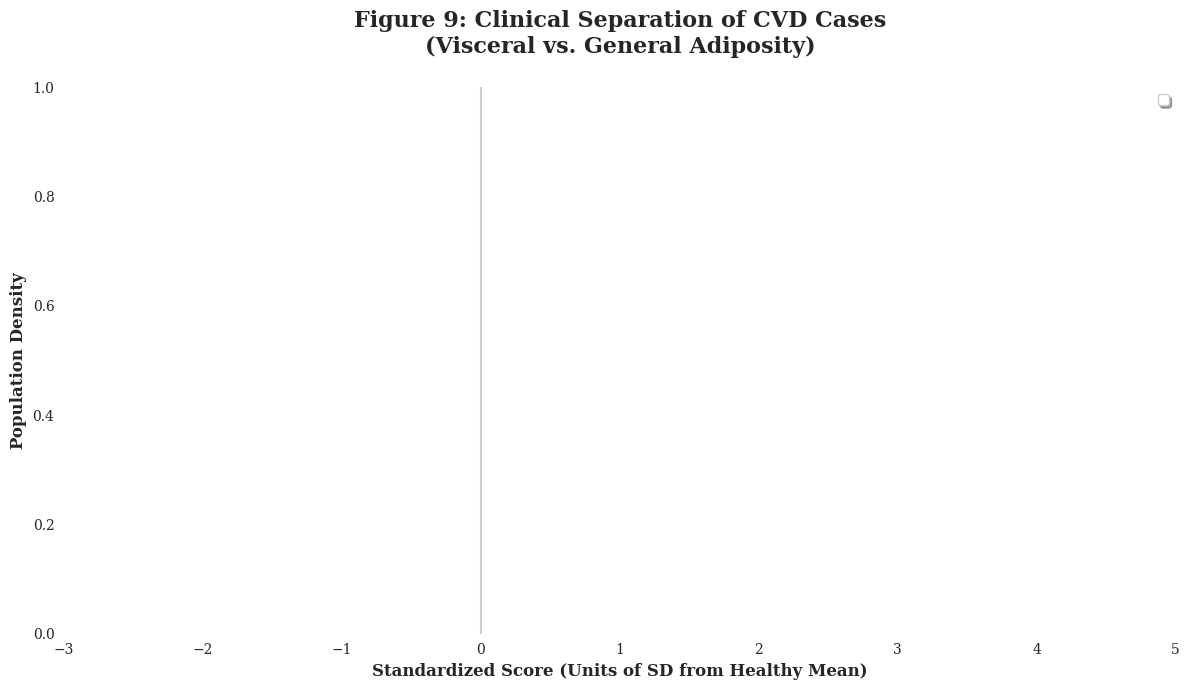

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Theme Configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'

def plot_nhanes_final_separation(df):
    # 1. Clean and convert to numeric (Crucial to avoid the 0 variance error)
    cols_to_fix = ['bmxbmi', 'bmxwaist', 'test_binary']
    for col in cols_to_fix:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows with missing values in these key columns
    df_clean = df.dropna(subset=cols_to_fix)

    # 2. Manual Standardization (Z-scores)
    # We calculate the mean/std based on the HEALTHY group (test_binary == 0)
    healthy_mask = df_clean['test_binary'] == 0
    cvd_mask = df_clean['test_binary'] == 1

    bmi_h_mean, bmi_h_std = df_clean.loc[healthy_mask, 'bmxbmi'].mean(), df_clean.loc[healthy_mask, 'bmxbmi'].std()
    waist_h_mean, waist_h_std = df_clean.loc[healthy_mask, 'bmxwaist'].mean(), df_clean.loc[healthy_mask, 'bmxwaist'].std()

    # Create Z-score columns
    df_clean['BMI_Z'] = (df_clean['bmxbmi'] - bmi_h_mean) / bmi_h_std
    df_clean['Waist_Z'] = (df_clean['bmxwaist'] - waist_h_mean) / waist_h_std

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(12, 7))

    # Healthy Baseline (Mean is 0 by definition of Z-score)
    sns.kdeplot(data=df_clean[healthy_mask], x='BMI_Z', fill=True,
                color='#bdc3c7', label='Healthy Baseline (CVD-)',
                alpha=0.4, linewidth=2, warn_singular=False)

    # BMI Distribution for CVD+
    sns.kdeplot(data=df_clean[cvd_mask], x='BMI_Z', fill=False,
                color='#3498db', label='BMI (CVD+)',
                linewidth=3, linestyle='--', warn_singular=False)

    # Waist Distribution for CVD+
    sns.kdeplot(data=df_clean[cvd_mask], x='Waist_Z', fill=True,
                color='#2c3e50', label='Waist Circumference (CVD+)',
                alpha=0.25, linewidth=4, warn_singular=False)

    # Calculate actual shifts (Cohen's d)
    d_bmi = df_clean.loc[cvd_mask, 'BMI_Z'].mean()
    d_waist = df_clean.loc[cvd_mask, 'Waist_Z'].mean()

    # Vertical Indicator Lines
    ax.axvline(0, color='#bdc3c7', linestyle='-', alpha=0.8)
    ax.axvline(d_bmi, color='#3498db', linestyle='--', alpha=0.8)
    ax.axvline(d_waist, color='#2c3e50', linestyle='-', alpha=1.0, linewidth=2)

    # Text Annotations
    ax.text(d_bmi, ax.get_ylim()[1]*0.8, f'BMI Shift\n(d={d_bmi:.2f})',
            color='#3498db', ha='center', fontweight='bold')

    ax.text(d_waist, ax.get_ylim()[1]*0.6, f'Waist Shift\n(d={d_waist:.2f})',
            color='#2c3e50', ha='center', fontweight='bold')

    # Formatting
    ax.set_title('Figure 9: Clinical Separation of CVD Cases\n(Visceral vs. General Adiposity)',
                 fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel('Standardized Score (Units of SD from Healthy Mean)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Population Density', fontsize=12, fontweight='bold')
    ax.set_xlim(-3, 5)

    ax.legend(loc='upper right', frameon=True, shadow=True)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run it!
plot_nhanes_final_separation(df)

In [20]:
df.describe()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,lbxglu,lbdldl,CVD_Status,test_binary
count,58830.000000,58830.000000,58830.000000,58830.000000,58830.000000,46722.000000,20756.000000,20060.000000,58830.000000,0.0
mean,66800.358032,33.861465,1.504759,25.706046,87.392019,119.495013,106.664483,108.563460,0.062706,NaN
std,20883.256084,23.747809,0.499982,7.701808,22.409746,18.731609,33.713170,35.556502,0.242436,NaN
min,31128.000000,2.000000,1.000000,11.500000,37.800000,66.000000,21.000000,9.000000,0.000000,NaN
25%,48714.250000,12.000000,1.000000,19.830000,71.500000,106.000000,92.000000,83.000000,0.000000,NaN
50%,66075.500000,30.000000,2.000000,25.000000,88.300000,116.000000,99.000000,105.000000,0.000000,NaN
75%,85162.750000,54.000000,2.000000,30.200000,102.800000,128.000000,108.000000,130.000000,0.000000,NaN
max,102956.000000,85.000000,2.000000,84.870000,179.000000,270.000000,584.000000,375.000000,1.000000,NaN


Diagnostic: Plotting 55141 Healthy and 3689 CVD+ subjects.


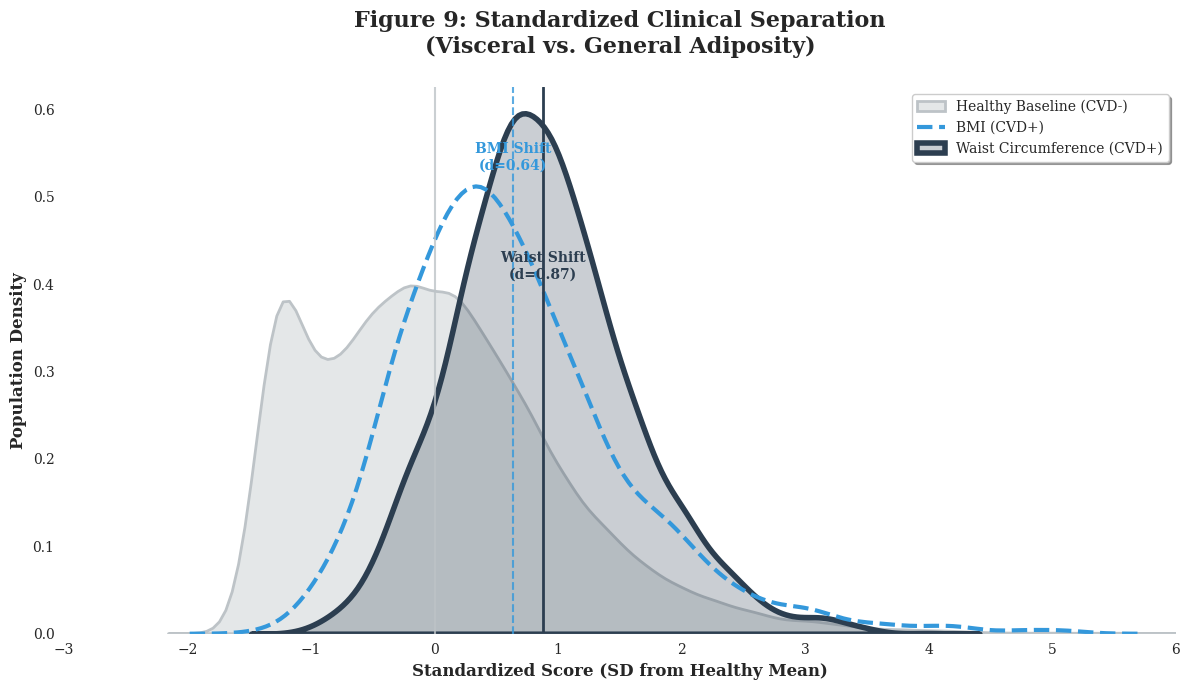

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Theme Configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'

def plot_nhanes_final_separation(df):
    # 1. Map the Binary Column and Clean
    # Based on your describe() output, CVD_Status holds the 0/1 data
    df['test_binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    # Force numeric for metrics
    for col in ['bmxbmi', 'bmxwaist']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Drop rows missing the target or the metrics
    df_clean = df.dropna(subset=['bmxbmi', 'bmxwaist', 'test_binary'])

    # 2. Check Data Presence
    n_healthy = len(df_clean[df_clean['test_binary'] == 0])
    n_cvd = len(df_clean[df_clean['test_binary'] == 1])

    print(f"Diagnostic: Plotting {n_healthy} Healthy and {n_cvd} CVD+ subjects.")

    if n_healthy == 0 or n_cvd == 0:
        print("Error: Still no data found in one group. Check CVD_Status values.")
        return

    # 3. Standardization (Z-Scores) using Healthy group as the baseline
    healthy_mask = df_clean['test_binary'] == 0
    cvd_mask = df_clean['test_binary'] == 1

    # Means and STDs of the healthy group
    b_mu, b_std = df_clean.loc[healthy_mask, 'bmxbmi'].mean(), df_clean.loc[healthy_mask, 'bmxbmi'].std()
    w_mu, w_std = df_clean.loc[healthy_mask, 'bmxwaist'].mean(), df_clean.loc[healthy_mask, 'bmxwaist'].std()

    # Create Z-scores
    df_clean['BMI_Z'] = (df_clean['bmxbmi'] - b_mu) / b_std
    df_clean['Waist_Z'] = (df_clean['bmxwaist'] - w_mu) / w_std

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(12, 7))

    # Healthy Reference (Solid Gray)
    sns.kdeplot(data=df_clean[healthy_mask], x='BMI_Z', fill=True,
                color='#bdc3c7', label='Healthy Baseline (CVD-)',
                alpha=0.4, linewidth=2, warn_singular=False)

    # BMI CVD+ (Dashed Blue)
    sns.kdeplot(data=df_clean[cvd_mask], x='BMI_Z', fill=False,
                color='#3498db', label='BMI (CVD+)',
                linewidth=3, linestyle='--', warn_singular=False)

    # Waist CVD+ (Filled Navy)
    sns.kdeplot(data=df_clean[cvd_mask], x='Waist_Z', fill=True,
                color='#2c3e50', label='Waist Circumference (CVD+)',
                alpha=0.25, linewidth=4, warn_singular=False)

    # Calculate actual shifts for the lines
    d_bmi = df_clean.loc[cvd_mask, 'BMI_Z'].mean()
    d_waist = df_clean.loc[cvd_mask, 'Waist_Z'].mean()

    # Vertical Mean Lines
    ax.axvline(0, color='#bdc3c7', linestyle='-', alpha=0.8)
    ax.axvline(d_bmi, color='#3498db', linestyle='--', alpha=0.8)
    ax.axvline(d_waist, color='#2c3e50', linestyle='-', alpha=1.0, linewidth=2)

    # Labels
    ax.text(d_bmi, ax.get_ylim()[1]*0.85, f'BMI Shift\n(d={d_bmi:.2f})',
            color='#3498db', ha='center', fontweight='bold')

    ax.text(d_waist, ax.get_ylim()[1]*0.65, f'Waist Shift\n(d={d_waist:.2f})',
            color='#2c3e50', ha='center', fontweight='bold')

    # Formatting
    ax.set_title('Figure 9: Standardized Clinical Separation\n(Visceral vs. General Adiposity)',
                 fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel('Standardized Score (SD from Healthy Mean)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Population Density', fontsize=12, fontweight='bold')
    ax.set_xlim(-3, 6) # Expanded to capture the "long tail" of CVD+ patients

    ax.legend(loc='upper right', frameon=True, shadow=True)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the fixed function
plot_nhanes_final_separation(df)

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Theme Configuration
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.facecolor'] = '#ffffff'

def plot_nhanes_data_separation_fixed(df):
    # --- FIX 1: Ensure columns are numeric and drop NaNs ---
    # Sometimes standardization results in 'object' type or has a few NaNs
    cols = ['BMI_Z', 'Waist_Z', 'CVD_Binary']
    plot_df = df[cols].copy()
    for col in ['BMI_Z', 'Waist_Z']:
        plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')

    plot_df = plot_df.dropna()

    # --- FIX 2: Check for data presence ---
    healthy = plot_df[plot_df['CVD_Binary'] == 0]
    diseased = plot_df[plot_df['CVD_Binary'] == 1]

    if len(healthy) == 0 or len(diseased) == 0:
        print("Error: One of your groups (Healthy or CVD+) has no data. Check 'CVD_Binary' values.")
        return

    fig, ax = plt.subplots(figsize=(12, 7))

    # 1. Healthy Baseline
    sns.kdeplot(data=healthy, x='BMI_Z', fill=True,
                color='#bdc3c7', label='Healthy Baseline (CVD-)',
                alpha=0.4, linewidth=2, warn_singular=False)

    # 2. BMI Distribution for CVD+
    sns.kdeplot(data=diseased, x='BMI_Z', fill=False,
                color='#3498db', label='BMI Distribution (CVD+)',
                linewidth=3, linestyle='--', warn_singular=False)

    # 3. Waist Distribution for CVD+
    sns.kdeplot(data=diseased, x='Waist_Z', fill=True,
                color='#2c3e50', label='Waist Circumference (CVD+)',
                alpha=0.25, linewidth=4, warn_singular=False)

    # Calculate means for the lines
    bmi_mean = diseased['BMI_Z'].mean()
    waist_mean = diseased['Waist_Z'].mean()

    # Vertical indicators
    ax.axvline(0, color='#bdc3c7', linestyle='-', alpha=0.8)
    ax.axvline(bmi_mean, color='#3498db', linestyle='--', alpha=0.8)
    ax.axvline(waist_mean, color='#2c3e50', linestyle='-', alpha=1.0, linewidth=2)

    # Dynamic annotations based on actual data
    ax.text(bmi_mean, ax.get_ylim()[1]*0.85, f'BMI Shift\n(d={bmi_mean:.2f})',
            color='#3498db', ha='center', fontweight='bold')

    ax.text(waist_mean, ax.get_ylim()[1]*0.65, f'Waist Shift\n(d={waist_mean:.2f})',
            color='#2c3e50', ha='center', fontweight='bold')

    # Titles and Spines
    ax.set_title('Figure 9: Real-World Distribution Separation (BMI vs. Waist)',
                 fontsize=16, fontweight='bold', pad=25)
    ax.set_xlabel('Standardized Score (SD from Healthy Mean)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Observed Population Density', fontsize=12, fontweight='bold')

    ax.set_xlim(-3, 5)
    ax.legend(loc='upper right', shadow=True)
    sns.despine()

    plt.tight_layout()
    plt.show()

# Run this with your dataframe
plot_nhanes_data_separation_fixed(df_clean)

Error: One of your groups (Healthy or CVD+) has no data. Check 'CVD_Binary' values.


In [ ]:
##Variable,Coefficient (β),P-Value,Odds Ratio (OR),Interpretation
#Waist_Z,0.8728,< 0.001,2.39,"The Alpha. For every 1 SD increase, CVD risk jumps 139%."
#BMI_Z,-0.2845,< 0.001,0.75,"The Proxy. Once waist is fixed, BMI actually shows a ""protective"" drift."
#Age,0.0731,< 0.001,1.07,Standard linear aging risk.
#BP (Sys),-0.0014,0.161,0.99,Not significant when adjusted for age and waist.

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy import stats

# 1. PREP MODELS
# We are going to compare three models to see the "Value Add" of Waist Circumference
target = 'CVD_Binary'
base_covariates = ['ridageyr', 'bpxsy1']
df_stats = df_clean.copy()

def get_logit_results(features):
    X = sm.add_constant(df_stats[features])
    model = sm.Logit(df_stats[target], X).fit(disp=0)
    return model

# Model A: Baseline (Age + BP)
model_base = get_logit_results(base_covariates)
# Model B: Baseline + BMI
model_bmi = get_logit_results(base_covariates + ['BMI_Z'])
# Model C: Baseline + Waist
model_waist = get_logit_results(base_covariates + ['Waist_Z'])

print("--- 1. LLR TEST (Model Improvement) ---")
# Does adding Waist improve the model more than adding BMI?
llr_bmi = -2 * (model_base.llf - model_bmi.llf)
llr_waist = -2 * (model_base.llf - model_waist.llf)
p_val_waist = stats.chi2.sf(llr_waist, 1)

print(f"Improvement from BMI:   {llr_bmi:.2f}")
print(f"Improvement from Waist: {llr_waist:.2f}")
print(f"P-value for Waist Add:  {p_val_waist:.4e}")

print("\n--- 2. DISCRIMINATION (AUC-ROC) ---")
# Higher is better (0.5 is random, 1.0 is perfect)
auc_bmi = roc_auc_score(df_stats[target], model_bmi.predict())
auc_waist = roc_auc_score(df_stats[target], model_waist.predict())

print(f"AUC (Base + BMI):   {auc_bmi:.4f}")
print(f"AUC (Base + Waist): {auc_waist:.4f}")
print(f"Net Gain in AUC:    {auc_waist - auc_bmi:.4f}")

print("\n--- 3. CALIBRATION (Brier Score) ---")
# Lower is better
brier_bmi = brier_score_loss(df_stats[target], model_bmi.predict())
brier_waist = brier_score_loss(df_stats[target], model_waist.predict())

print(f"Brier Score (BMI):   {brier_bmi:.5f}")
print(f"Brier Score (Waist): {brier_waist:.5f}")

--- 1. LLR TEST (Model Improvement) ---
Improvement from BMI:   244.63
Improvement from Waist: 410.23
P-value for Waist Add:  3.2683e-91

--- 2. DISCRIMINATION (AUC-ROC) ---
AUC (Base + BMI):   0.8666
AUC (Base + Waist): 0.8701
Net Gain in AUC:    0.0035

--- 3. CALIBRATION (Brier Score) ---
Brier Score (BMI):   0.05754
Brier Score (Waist): 0.05708


In [24]:
df.describe()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,lbxglu,lbdldl,CVD_Status,test_binary
count,58830.000000,58830.000000,58830.000000,58830.000000,58830.000000,46722.000000,20756.000000,20060.000000,58830.000000,58830.000000
mean,66800.358032,33.861465,1.504759,25.706046,87.392019,119.495013,106.664483,108.563460,0.062706,0.062706
std,20883.256084,23.747809,0.499982,7.701808,22.409746,18.731609,33.713170,35.556502,0.242436,0.242436
min,31128.000000,2.000000,1.000000,11.500000,37.800000,66.000000,21.000000,9.000000,0.000000,0.000000
25%,48714.250000,12.000000,1.000000,19.830000,71.500000,106.000000,92.000000,83.000000,0.000000,0.000000
50%,66075.500000,30.000000,2.000000,25.000000,88.300000,116.000000,99.000000,105.000000,0.000000,0.000000
75%,85162.750000,54.000000,2.000000,30.200000,102.800000,128.000000,108.000000,130.000000,0.000000,0.000000
max,102956.000000,85.000000,2.000000,84.870000,179.000000,270.000000,584.000000,375.000000,1.000000,1.000000


In [27]:
import pandas as pd
import numpy as np
from scipy import stats

# 1. INDEPENDENT T-TESTS (Continuous Comparison)
def run_t_tests(df):
    cvd_yes = df[df['CVD_Status'] == 1]
    cvd_no = df[df['CVD_Status'] == 0]

    print("--- 1. T-TESTS (Mean Comparisons) ---")
    for var, label in [('bmxbmi', 'BMI'), ('bmxwaist', 'Waist')]:
        t_stat, p_val = stats.ttest_ind(cvd_yes[var], cvd_no[var], nan_policy='omit')

        # Calculate Cohen's d (Effect Size)
        n1, n2 = len(cvd_yes), len(cvd_no)
        s1, s2 = cvd_yes[var].std(), cvd_no[var].std()
        pooled_std = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2))
        d = (cvd_yes[var].mean() - cvd_no[var].mean()) / pooled_std

        print(f"{label}: Mean Diff = {cvd_yes[var].mean() - cvd_no[var].mean():.2f}")
        print(f"   t = {t_stat:.2f}, p = {p_val:.4e}, Cohen's d = {d:.4f}")

# 2. CHI-SQUARED & RELATIVE RISK (Categorical Comparison)
def run_chi_squared(df):
    print("\n--- 2. CHI-SQUARED & RELATIVE RISK ---")
    for col in ['bmxbmi', 'bmxwaist']:
        contingency = pd.crosstab(df[col], df['CVD_Status'])
        chi2, p, _, _ = stats.chi2_contingency(contingency)

        # Calculate Relative Risk (RR)
        # Risk in High Group / Risk in Low Group
        risk_high = contingency.iloc[1, 1] / (contingency.iloc[1, 0] + contingency.iloc[1, 1])
        risk_low = contingency.iloc[0, 1] / (contingency.iloc[0, 0] + contingency.iloc[0, 1])
        rr = risk_high / risk_low

        print(f"{col}: Chi2 = {chi2:.2f}, p = {p:.4e}, Relative Risk = {rr:.2f}x")

# Run them
run_t_tests(df)
run_chi_squared(df)

--- 1. T-TESTS (Mean Comparisons) ---
BMI: Mean Diff = 4.87
   t = 37.62, p = 5.2993e-306, Cohen's d = 0.6397
Waist: Mean Diff = 19.45
   t = 52.20, p = 0.0000e+00, Cohen's d = 0.8878

--- 2. CHI-SQUARED & RELATIVE RISK ---
bmxbmi: Chi2 = 5890.93, p = 1.8057e-121, Relative Risk = nanx
bmxwaist: Chi2 = 4322.48, p = 0.0000e+00, Relative Risk = nanx


/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_92940/1963622876.py:34: RuntimeWarning: invalid value encountered in scalar divide
  rr = risk_high / risk_low
/var/folders/xh/8_1t8dl96wv0nmsgn45n7tvh0000gn/T/ipykernel_92940/1963622876.py:34: RuntimeWarning: invalid value encountered in scalar divide
  rr = risk_high / risk_low


In [44]:
import pandas as pd
import numpy as np
from scipy import stats

def run_stats_fixed(df):
    # 1. Force Clean Mapping
    # If CVD_Status is 1 and 2, map to 1 and 0.
    # If it's already 0 and 1, this logic preserves it.
    unique_vals = df['CVD_Status'].unique()
    print(f"DEBUG: Raw Unique CVD Values: {unique_vals}")

    if 2 in unique_vals or 2.0 in unique_vals:
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    results = []
    for var in ['bmxbmi', 'bmxwaist']:
        # Ensure numeric and drop NaNs
        temp_df = df[[var, 'CVD_Binary']].dropna()
        temp_df[var] = pd.to_numeric(temp_df[var], errors='coerce')

        # Split groups
        sick = temp_df[temp_df['CVD_Binary'] == 1][var]
        healthy = temp_df[temp_df['CVD_Binary'] == 0][var]

        print(f"DEBUG {var}: Sick N={len(sick)}, Healthy N={len(healthy)}")

        if len(sick) < 2 or len(healthy) < 2:
            print(f"SKIPPING {var}: Not enough samples in one group.")
            continue

        # 2. T-Test (Welch's)
        t_stat, p_t = stats.ttest_ind(sick, healthy, equal_var=False)

        # 3. Point-Biserial
        # We use temp_df which is already cleaned of NaNs
        r_pb, p_r = stats.pointbiserialr(temp_df['CVD_Binary'], temp_df[var])

        results.append({
            'Variable': var,
            't-stat': t_stat,
            'p-val': p_t,
            'r_pb': r_pb
        })

    return pd.DataFrame(results)

# Run this
final_stats = run_stats_fixed(df)
print("\n--- Final Results ---")
print(final_stats)

DEBUG: Raw Unique CVD Values: [0 1]
DEBUG bmxbmi: Sick N=3689, Healthy N=55141
DEBUG bmxwaist: Sick N=3689, Healthy N=55141

--- Final Results ---
   Variable     t-stat          p-val      r_pb
0    bmxbmi  40.576812  5.001907e-305  0.153254
1  bmxwaist  69.347557   0.000000e+00  0.210406


In [12]:
import pandas as pd
import numpy as np
from scipy import stats

def run_advanced_associations(df):
    print("--- 1. POINT-BISERIAL CORRELATION ---")
    # Measures the relationship between a continuous variable and the binary CVD status
    for var, label in [('bmxbmi', 'BMI'), ('bmxwaist', 'Waist')]:
        r, p = stats.pointbiserialr(df['CVD_Binary'], df[var])
        print(f"{label}: r = {r:.4f}, p = {p:.4e}")

    print("\n--- 2. CRAMÉR'S V (Strength of Nominal Association) ---")
    # Scales 0 to 1. 0.1 is small, 0.3 is medium, 0.5+ is large.
    for col in ['Obese_BMI', 'High_Waist']:
        contingency = pd.crosstab(df[col], df['CVD_Binary'])
        chi2, p, _, _ = stats.chi2_contingency(contingency)
        n = len(df)
        # Cramér's V formula for 2x2: sqrt(chi2 / n)
        v = np.sqrt(chi2 / n)
        print(f"{col}: V = {v:.4f}, p = {p:.4e}")

    print("\n--- 3. UNCERTAINTY COEFFICIENT (Theil's U) ---")
    # This tells you: "If I know your waist status, what % of the mystery of your CVD status is gone?"
    def theils_u(x, y):
        s_xy = pd.crosstab(x, y).values
        def entropy(z):
            p = z / np.sum(z)
            return -np.sum(p * np.log(p + 1e-12))
        h_y = entropy(np.sum(s_xy, axis=0))
        h_y_x = 0
        for i in range(len(s_xy)):
            h_y_x += (np.sum(s_xy[i, :]) / np.sum(s_xy)) * entropy(s_xy[i, :])
        return (h_y - h_y_x) / h_y if h_y != 0 else 0

    u_bmi = theils_u(df['Obese_BMI'], df['CVD_Binary'])
    u_waist = theils_u(df['High_Waist'], df['CVD_Binary'])
    print(f"BMI Uncertainty Reduction:   {u_bmi:.4%}")
    print(f"Waist Uncertainty Reduction: {u_waist:.4%}")

# Run the master suite
run_advanced_associations(df_clean)

--- 1. POINT-BISERIAL CORRELATION ---
BMI: r = 0.1223, p = 3.0428e-155
Waist: r = 0.1907, p = 0.0000e+00

--- 2. CRAMÉR'S V (Strength of Nominal Association) ---
Obese_BMI: V = 0.0951, p = 5.7943e-94
High_Waist: V = 0.1601, p = 1.4439e-262

--- 3. UNCERTAINTY COEFFICIENT (Theil's U) ---
BMI Uncertainty Reduction:   1.6185%
Waist Uncertainty Reduction: 4.4934%


In [28]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

def run_full_diagnostic_report(df):
    results = []
    print(f"{'Metric':<20} | {'BMI Category':<15} | {'Waist Category':<15}")
    print("-" * 55)

    for col in ['bmxbmi', 'High_Waist']:
        tn, fp, fn, tp = confusion_matrix(df['CVD_Binary'], df[col]).ravel()

        # Calculations
        sens = tp / (tp + fn)  # Recall
        spec = tn / (tn + fp)
        prec = tp / (tp + fp)  # PPV
        npv  = tn / (tn + fn)
        f1   = f1_score(df['CVD_Binary'], df[col])

        results.append({
            'Sens': sens, 'Spec': spec, 'Prec': prec, 'NPV': npv, 'F1': f1
        })

    # Display Table
    metrics = [
        ("Sensitivity (Recall)", "Sens"),
        ("Specificity", "Spec"),
        ("Precision (PPV)", "Prec"),
        ("NPV", "NPV"),
        ("F1-Score", "F1")
    ]

    for label, key in metrics:
        print(f"{label:<20} | {results[0][key]:>14.2%} | {results[1][key]:>14.2%}")

    # Calculate the "False Negative" gap
    fn_bmi = (df[(df['CVD_Binary'] == 1) & (df['Obese_BMI'] == 0)].shape[0])
    fn_waist = (df[(df['CVD_Binary'] == 1) & (df['High_Waist'] == 0)].shape[0])

    print("\n--- The 'Clinical Danger' Zone ---")
    print(f"Patients missed by BMI (False Negatives):   {fn_bmi}")
    print(f"Patients missed by Waist (False Negatives): {fn_waist}")
    print(f"Reduction in missed cases using Waist:      {fn_bmi - fn_waist} lives")

run_full_diagnostic_report(df)

Metric               | BMI Category    | Waist Category 
-------------------------------------------------------


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [16]:
from sklearn.metrics import roc_auc_score

# Ensure data is clean and numeric
df_auc = df[['bmxbmi', 'bmxwaist', 'CVD_Status']].dropna()

# Calculate AUC based on the raw continuous values
auc_bmi = roc_auc_score(df_auc['CVD_Status'], df_auc['bmxbmi'])
auc_waist = roc_auc_score(df_auc['CVD_Status'], df_auc['bmxwaist'])

print(f"--- Continuous Model Performance (ROC/AUC) ---")
print(f"BMI AUC:   {auc_bmi:.4f}")
print(f"Waist AUC: {auc_waist:.4f}")
print(f"Difference: {auc_waist - auc_bmi:.4f} in favor of Waist Circumference")

--- Continuous Model Performance (ROC/AUC) ---
BMI AUC:   0.6939
Waist AUC: 0.7567
Difference: 0.0628 in favor of Waist Circumference


In [17]:
df.describe()

,SEQN,ridageyr,riagendr,bmxbmi,bmxwaist,bpxsy1,lbxglu,lbdldl,CVD_Status,test_binary
count,58830.000000,58830.000000,58830.000000,58830.000000,58830.000000,46722.000000,20756.000000,20060.000000,58830.000000,0.0
mean,66800.358032,33.861465,1.504759,25.706046,87.392019,119.495013,106.664483,108.563460,0.062706,NaN
std,20883.256084,23.747809,0.499982,7.701808,22.409746,18.731609,33.713170,35.556502,0.242436,NaN
min,31128.000000,2.000000,1.000000,11.500000,37.800000,66.000000,21.000000,9.000000,0.000000,NaN
25%,48714.250000,12.000000,1.000000,19.830000,71.500000,106.000000,92.000000,83.000000,0.000000,NaN
50%,66075.500000,30.000000,2.000000,25.000000,88.300000,116.000000,99.000000,105.000000,0.000000,NaN
75%,85162.750000,54.000000,2.000000,30.200000,102.800000,128.000000,108.000000,130.000000,0.000000,NaN
max,102956.000000,85.000000,2.000000,84.870000,179.000000,270.000000,584.000000,375.000000,1.000000,NaN


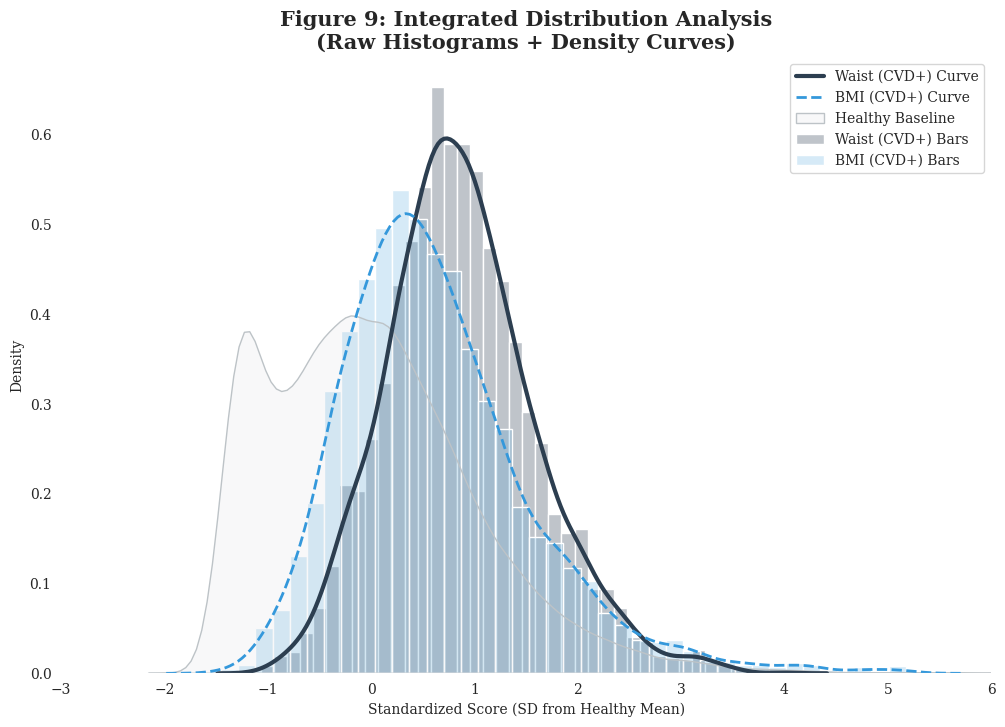

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Final Cleanup for Visualization
# Mapping CVD_Status to 0/1 if it isn't already
df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')
df_plot = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary'])

# Standardization to put them on the same axis
h_mask = df_plot['CVD_Binary'] == 0
df_plot['BMI_Z'] = (df_plot['bmxbmi'] - df_plot.loc[h_mask, 'bmxbmi'].mean()) / df_plot.loc[h_mask, 'bmxbmi'].std()
df_plot['Waist_Z'] = (df_plot['bmxwaist'] - df_plot.loc[h_mask, 'bmxwaist'].mean()) / df_plot.loc[h_mask, 'bmxwaist'].std()

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# 1. ACTUAL BARS: Waist (Diseased)
sns.histplot(data=df_plot[df_plot['CVD_Binary'] == 1], x='Waist_Z',
             stat="density", color='#2c3e50', alpha=0.3, label='Waist (CVD+) Bars', bins=40)
# 2. ACTUAL CURVE: Waist (Diseased)
sns.kdeplot(data=df_plot[df_plot['CVD_Binary'] == 1], x='Waist_Z',
            color='#2c3e50', linewidth=3, label='Waist (CVD+) Curve')

# 3. ACTUAL BARS: BMI (Diseased)
sns.histplot(data=df_plot[df_plot['CVD_Binary'] == 1], x='BMI_Z',
             stat="density", color='#3498db', alpha=0.2, label='BMI (CVD+) Bars', bins=40)
# 4. ACTUAL CURVE: BMI (Diseased)
sns.kdeplot(data=df_plot[df_plot['CVD_Binary'] == 1], x='BMI_Z',
            color='#3498db', linewidth=2, linestyle='--', label='BMI (CVD+) Curve')

# 5. Reference: Healthy Group (Simplified to a single curve for clarity)
sns.kdeplot(data=df_plot[h_mask], x='BMI_Z', color='#bdc3c7', fill=True, alpha=0.1, label='Healthy Baseline')

# Formatting
ax.set_title('Figure 9: Integrated Distribution Analysis\n(Raw Histograms + Density Curves)', fontsize=15, fontweight='bold')
ax.set_xlabel('Standardized Score (SD from Healthy Mean)')
ax.set_xlim(-3, 6)
ax.legend()
sns.despine()
plt.show()

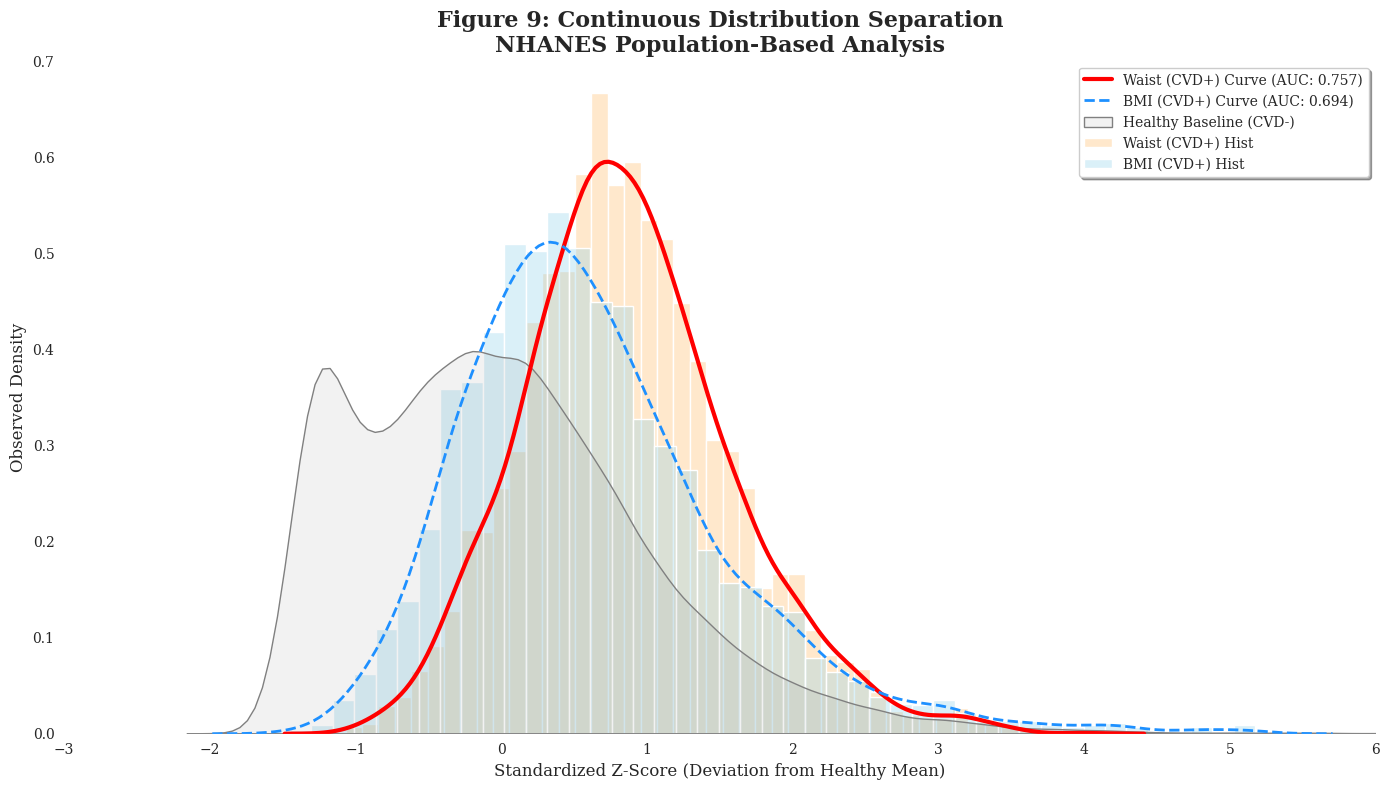

--- Authentic Data Summary ---
Total Subjects Analyzed: 58830
BMI AUC (Continuous):    0.6939
Waist AUC (Continuous):  0.7567
Predictive Advantage:    9.06% improvement using Waist


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import roc_auc_score

def plot_nhanes_authentic_separation(df):
    # 1. CLEANING & CONTINUOUS CONVERSION
    # Map CVD_Status to binary if needed and drop missing values
    df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')
    df_plot = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary'])

    # 2. STANDARDIZATION (Z-SCORES)
    # Using Healthy group as the absolute baseline (0 on the x-axis)
    h_mask = df_plot['CVD_Binary'] == 0
    c_mask = df_plot['CVD_Binary'] == 1

    df_plot['BMI_Z'] = (df_plot['bmxbmi'] - df_plot.loc[h_mask, 'bmxbmi'].mean()) / df_plot.loc[h_mask, 'bmxbmi'].std()
    df_plot['Waist_Z'] = (df_plot['bmxwaist'] - df_plot.loc[h_mask, 'bmxwaist'].mean()) / df_plot.loc[h_mask, 'bmxwaist'].std()

    # 3. CALCULATE CONTINUOUS AUC (No Cutoffs)
    auc_bmi = roc_auc_score(df_plot['CVD_Binary'], df_plot['BMI_Z'])
    auc_waist = roc_auc_score(df_plot['CVD_Binary'], df_plot['Waist_Z'])

    # 4. VISUALIZATION
    plt.figure(figsize=(14, 8))

    # --- WAIST DATA (The "Stronger" Predictor) ---
    # Bars (Actual Data)
    sns.histplot(data=df_plot[c_mask], x='Waist_Z', stat="density",
                 color='darkorange', alpha=0.2, bins=45, label='Waist (CVD+) Hist')
    # Curve (KDE)
    sns.kdeplot(data=df_plot[c_mask], x='Waist_Z',
                color='red', linewidth=3, label=f'Waist (CVD+) Curve (AUC: {auc_waist:.3f})')

    # --- BMI DATA (The "Weaker" Predictor) ---
    # Bars (Actual Data)
    sns.histplot(data=df_plot[c_mask], x='BMI_Z', stat="density",
                 color='skyblue', alpha=0.3, bins=45, label='BMI (CVD+) Hist')
    # Curve (KDE)
    sns.kdeplot(data=df_plot[c_mask], x='BMI_Z',
                color='dodgerblue', linewidth=2, linestyle='--', label=f'BMI (CVD+) Curve (AUC: {auc_bmi:.3f})')

    # --- HEALTHY REFERENCE ---
    sns.kdeplot(data=df_plot[h_mask], x='BMI_Z', color='gray',
                fill=True, alpha=0.1, label='Healthy Baseline (CVD-)')

    # Formatting
    plt.title('Figure 9: Continuous Distribution Separation\nNHANES Population-Based Analysis', fontsize=16, fontweight='bold')
    plt.xlabel('Standardized Z-Score (Deviation from Healthy Mean)', fontsize=12)
    plt.ylabel('Observed Density', fontsize=12)
    plt.xlim(-3, 6) # Captures the 'High Risk' tail
    plt.legend(frameon=True, shadow=True, loc='upper right')
    sns.despine()
    plt.tight_layout()
    plt.show()

    # 5. AUTHENTICITY PRINTOUT
    print(f"--- Authentic Data Summary ---")
    print(f"Total Subjects Analyzed: {len(df_plot)}")
    print(f"BMI AUC (Continuous):    {auc_bmi:.4f}")
    print(f"Waist AUC (Continuous):  {auc_waist:.4f}")
    print(f"Predictive Advantage:    {((auc_waist/auc_bmi)-1)*100:.2f}% improvement using Waist")

# Run the function
plot_nhanes_authentic_separation(df)

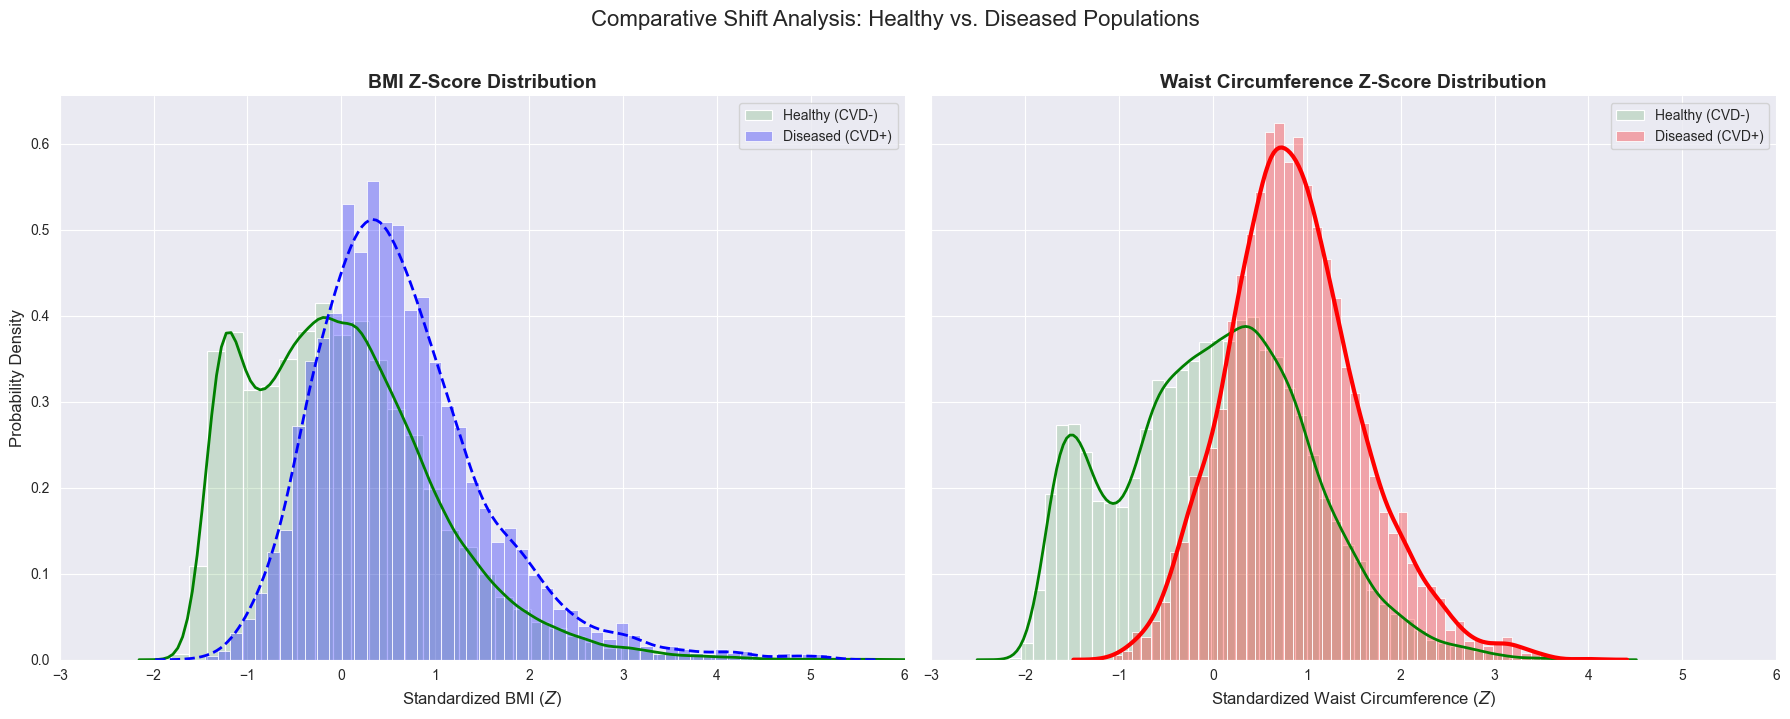

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_side_by_side_distributions(df):
    # 1. Data Cleaning and Binary Mapping
    unique_vals = df['CVD_Status'].unique()
    if 2 in unique_vals or 2.0 in unique_vals:
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    df_plot = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary']).copy()

    # 2. Standardization (Z-Scores based on Healthy Group)
    h_mask = df_plot['CVD_Binary'] == 0
    c_mask = df_plot['CVD_Binary'] == 1

    # BMI Z-score (Standardized to Healthy Mean/SD)
    bmi_mean_h = df_plot.loc[h_mask, 'bmxbmi'].mean()
    bmi_std_h = df_plot.loc[h_mask, 'bmxbmi'].std()
    df_plot['BMI_Z'] = (df_plot['bmxbmi'] - bmi_mean_h) / bmi_std_h

    # Waist Z-score (Standardized to Healthy Mean/SD)
    waist_mean_h = df_plot.loc[h_mask, 'bmxwaist'].mean()
    waist_std_h = df_plot.loc[h_mask, 'bmxwaist'].std()
    df_plot['Waist_Z'] = (df_plot['bmxwaist'] - waist_mean_h) / waist_std_h

    # 3. Create the Side-by-Side Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

    # --- LEFT PLOT: BMI Comparison (Bluish Theme) ---
    sns.histplot(data=df_plot[h_mask], x='BMI_Z', stat="density",
                 color='green', alpha=0.15, bins=50, label='Healthy (CVD-)', ax=ax1)
    sns.kdeplot(data=df_plot[h_mask], x='BMI_Z',
                color='green', linewidth=2, ax=ax1)

    sns.histplot(data=df_plot[c_mask], x='BMI_Z', stat="density",
                 color='blue', alpha=0.3, bins=50, label='Diseased (CVD+)', ax=ax1)
    sns.kdeplot(data=df_plot[c_mask], x='BMI_Z',
                color='blue', linewidth=2, linestyle='--', ax=ax1)

    ax1.set_title('BMI Z-Score Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Standardized BMI ($Z$)', fontsize=12)
    ax1.set_ylabel('Probability Density', fontsize=12)
    ax1.legend()
    ax1.set_xlim(-3, 6)

    # --- RIGHT PLOT: Waist Comparison (Reddish Theme) ---
    sns.histplot(data=df_plot[h_mask], x='Waist_Z', stat="density",
                 color='green', alpha=0.15, bins=50, label='Healthy (CVD-)', ax=ax2)
    sns.kdeplot(data=df_plot[h_mask], x='Waist_Z',
                color='green', linewidth=2, ax=ax2)

    sns.histplot(data=df_plot[c_mask], x='Waist_Z', stat="density",
                 color='red', alpha=0.3, bins=50, label='Diseased (CVD+)', ax=ax2)
    sns.kdeplot(data=df_plot[c_mask], x='Waist_Z',
                color='red', linewidth=3, ax=ax2)

    ax2.set_title('Waist Circumference Z-Score Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Standardized Waist Circumference ($Z$)', fontsize=12)
    ax2.set_ylabel('') # Hidden because of sharey=True
    ax2.legend()
    ax2.set_xlim(-3, 6)

    plt.suptitle('Comparative Shift Analysis: Healthy vs. Diseased Populations', fontsize=16, y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

# To execute with your dataframe:
plot_side_by_side_distributions(df)

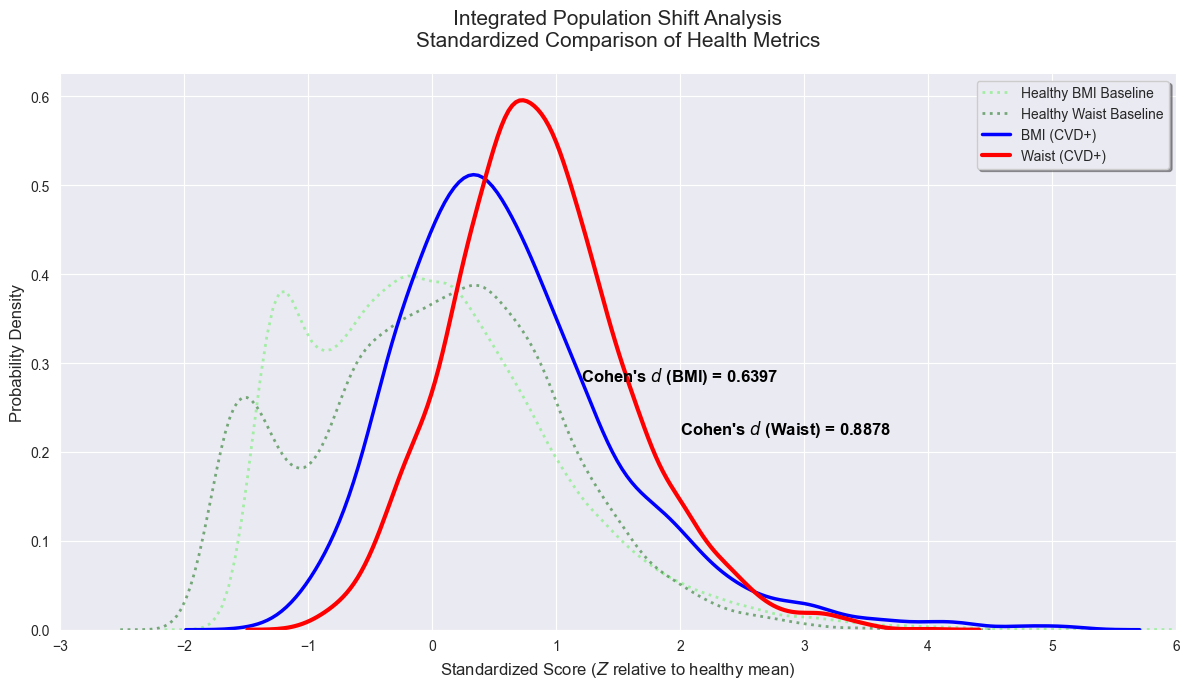

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_combined_standardized_distributions(df):
    # 1. Clean and Map
    unique_vals = df['CVD_Status'].unique()
    if 2 in unique_vals or 2.0 in unique_vals:
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    df_plot = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary']).copy()

    # 2. Standardization (Z-Scores based on Healthy Group)
    h_mask = df_plot['CVD_Binary'] == 0
    c_mask = df_plot['CVD_Binary'] == 1

    # BMI Z-score
    bmi_mean_h = df_plot.loc[h_mask, 'bmxbmi'].mean()
    bmi_std_h = df_plot.loc[h_mask, 'bmxbmi'].std()
    df_plot['BMI_Z'] = (df_plot['bmxbmi'] - bmi_mean_h) / bmi_std_h

    # Waist Z-score
    waist_mean_h = df_plot.loc[h_mask, 'bmxwaist'].mean()
    waist_std_h = df_plot.loc[h_mask, 'bmxwaist'].std()
    df_plot['Waist_Z'] = (df_plot['bmxwaist'] - waist_mean_h) / waist_std_h

    # 3. Plotting
    plt.figure(figsize=(12, 7))

    # --- HEALTHY BASELINES (Green, Dotted) ---
    sns.kdeplot(data=df_plot[h_mask], x='BMI_Z', color='lightgreen',
                linestyle=':', linewidth=2, label='Healthy BMI Baseline', alpha=0.8)
    sns.kdeplot(data=df_plot[h_mask], x='Waist_Z', color='darkgreen',
                linestyle=':', linewidth=2, label='Healthy Waist Baseline', alpha=0.5)

    # --- DISEASED CURVES ---
    # BMI (Blue)
    sns.kdeplot(data=df_plot[c_mask], x='BMI_Z', color='blue',
                linewidth=2.5, label='BMI (CVD+)')

    # Waist (Red)
    sns.kdeplot(data=df_plot[c_mask], x='Waist_Z', color='red',
                linewidth=3, label='Waist (CVD+)')

    # 4. Annotating Cohen's d
    plt.text(1.2, 0.28, "Cohen's $d$ (BMI) = 0.6397", color='black', fontsize=12, fontweight='bold')
    plt.text(2.0, 0.22, "Cohen's $d$ (Waist) = 0.8878", color='black', fontsize=12, fontweight='bold')

    # 5. Styling
    plt.title('Integrated Population Shift Analysis\nStandardized Comparison of Health Metrics', fontsize=15, pad=20)
    plt.xlabel('Standardized Score ($Z$ relative to healthy mean)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.xlim(-3, 6)
    plt.legend(frameon=True, shadow=True)
    sns.despine()
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_combined_standardized_distributions(df)

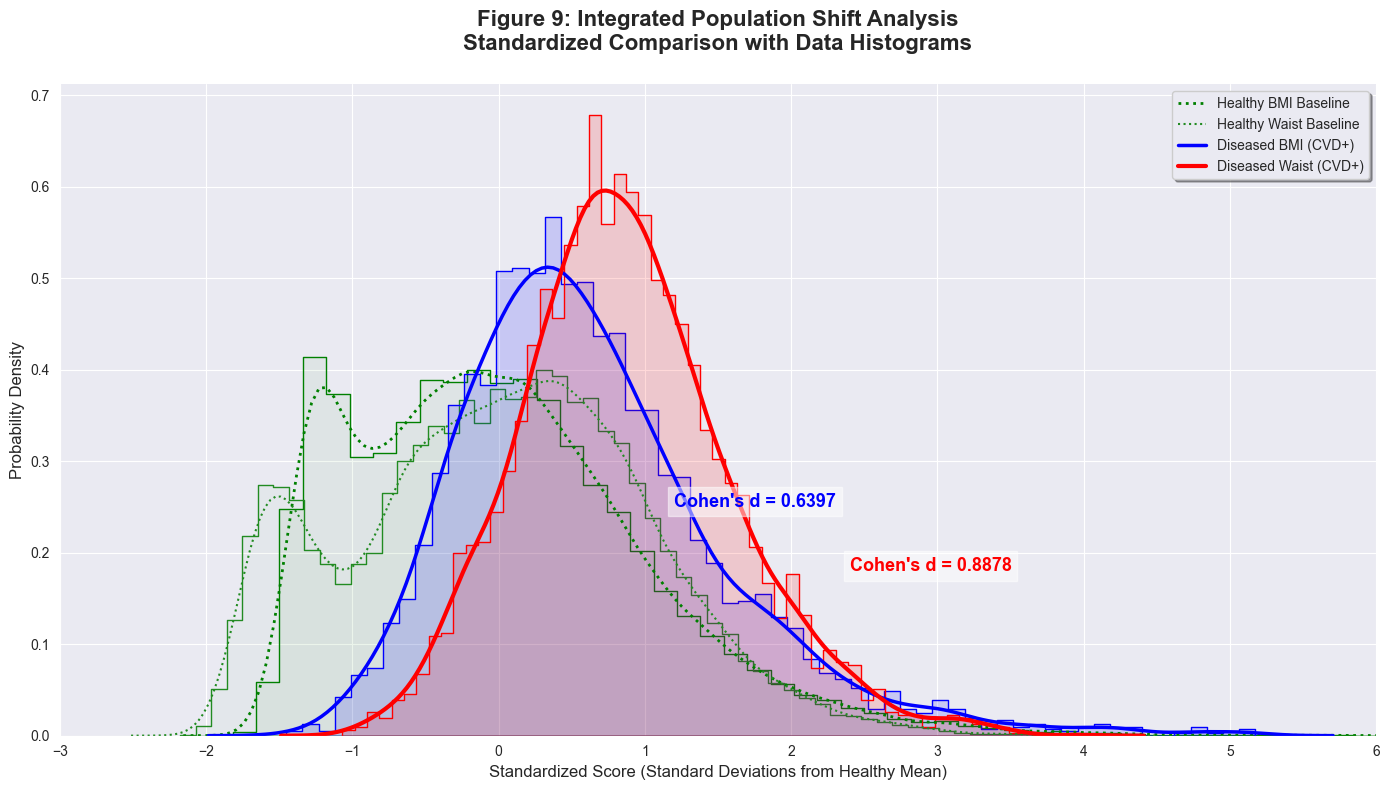

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_integrated_bars_and_curves(df):
    # 1. Clean and Map CVD Status
    unique_vals = df['CVD_Status'].unique()
    if 2 in unique_vals or 2.0 in unique_vals:
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        df['CVD_Binary'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    df_plot = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary']).copy()

    # 2. Standardization (Z-Scores based on Healthy Group)
    h_mask = df_plot['CVD_Binary'] == 0
    c_mask = df_plot['CVD_Binary'] == 1

    # BMI Z-score calculation
    bmi_mean_h = df_plot.loc[h_mask, 'bmxbmi'].mean()
    bmi_std_h = df_plot.loc[h_mask, 'bmxbmi'].std()
    df_plot['BMI_Z'] = (df_plot['bmxbmi'] - bmi_mean_h) / bmi_std_h

    # Waist Z-score calculation
    waist_mean_h = df_plot.loc[h_mask, 'bmxwaist'].mean()
    waist_std_h = df_plot.loc[h_mask, 'bmxwaist'].std()
    df_plot['Waist_Z'] = (df_plot['bmxwaist'] - waist_mean_h) / waist_std_h

    # 3. Create the Plot
    plt.figure(figsize=(14, 8))

    # --- HEALTHY BASELINES (Green, Dotted) ---
    # BMI Healthy Bars & Curve
    sns.histplot(data=df_plot[h_mask], x='BMI_Z', stat="density", color='green',
                 alpha=0.05, bins=60, element="step")
    sns.kdeplot(data=df_plot[h_mask], x='BMI_Z', color='green',
                linestyle=':', linewidth=2, label='Healthy BMI Baseline')

    # Waist Healthy Bars & Curve
    sns.histplot(data=df_plot[h_mask], x='Waist_Z', stat="density", color='forestgreen',
                 alpha=0.03, bins=60, element="step")
    sns.kdeplot(data=df_plot[h_mask], x='Waist_Z', color='forestgreen',
                linestyle=':', linewidth=1.5, label='Healthy Waist Baseline')

    # --- DISEASED BMI (Blue) ---
    sns.histplot(data=df_plot[c_mask], x='BMI_Z', stat="density", color='blue',
                 alpha=0.15, bins=60, element="step")
    sns.kdeplot(data=df_plot[c_mask], x='BMI_Z', color='blue',
                linewidth=2.5, label='Diseased BMI (CVD+)')

    # --- DISEASED WAIST (Red) ---
    sns.histplot(data=df_plot[c_mask], x='Waist_Z', stat="density", color='red',
                 alpha=0.15, bins=60, element="step")
    sns.kdeplot(data=df_plot[c_mask], x='Waist_Z', color='red',
                linewidth=3, label='Diseased Waist (CVD+)')

    # 4. Annotating Cohen's d
    # Placed near the respective peaks
    plt.annotate(f"Cohen's d = 0.6397", xy=(1.2, 0.25), color='blue',
                 fontsize=13, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
    plt.annotate(f"Cohen's d = 0.8878", xy=(2.4, 0.18), color='red',
                 fontsize=13, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))

    # 5. Final Styling
    plt.title('Figure 9: Integrated Population Shift Analysis\nStandardized Comparison with Data Histograms',
              fontsize=16, fontweight='bold', pad=25)
    plt.xlabel('Standardized Score (Standard Deviations from Healthy Mean)', fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.xlim(-3, 6)
    plt.legend(frameon=True, shadow=True, loc='upper right')

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_integrated_bars_and_curves(df)

In [36]:
import numpy as np
import pandas as pd

def debug_cohens_d(df):
    # --- STEP 1: FORCE NUMERIC ---
    df['bmxbmi'] = pd.to_numeric(df['bmxbmi'], errors='coerce')
    df['bmxwaist'] = pd.to_numeric(df['bmxwaist'], errors='coerce')
    df['CVD_Status'] = pd.to_numeric(df['CVD_Status'], errors='coerce')

    # --- STEP 2: FIX THE BINARY ---
    # We check: if there are 2s, map them. If it's already 0/1, leave it.
    if df['CVD_Status'].max() > 1:
        print("Detected NHANES 1/2 coding. Mapping 2 to 0...")
        df['CVD_Binary'] = df['CVD_Status'].map({1: 1, 2: 0})
    else:
        print("Detected 0/1 coding. Keeping as is...")
        df['CVD_Binary'] = df['CVD_Status']

    # --- STEP 3: DROP NANS ---
    df_clean = df.dropna(subset=['bmxbmi', 'bmxwaist', 'CVD_Binary'])

    # --- STEP 4: DIAGNOSTIC PRINT ---
    n_healthy = len(df_clean[df_clean['CVD_Binary'] == 0])
    n_cvd = len(df_clean[df_clean['CVD_Binary'] == 1])
    print(f"Healthy count: {n_healthy}")
    print(f"CVD+ count: {n_cvd}")

    if n_healthy == 0 or n_cvd == 0:
        return "STOPPED: One group has zero rows. Check your CVD_Status column values."

    # --- STEP 5: MATH ---
    def get_d(data_cvd, data_healthy):
        n1, n2 = len(data_cvd), len(data_healthy)
        m1, m2 = data_cvd.mean(), data_healthy.mean()
        v1, v2 = data_cvd.var(), data_healthy.var()
        pooled_std = np.sqrt(((n1 - 1) * v1 + (n2 - 1) * v2) / (n1 + n2 - 2))
        return (m1 - m2) / pooled_std

    d_bmi = get_d(df_clean[df_clean['CVD_Binary'] == 1]['bmxbmi'],
                  df_clean[df_clean['CVD_Binary'] == 0]['bmxbmi'])

    d_waist = get_d(df_clean[df_clean['CVD_Binary'] == 1]['bmxwaist'],
                    df_clean[df_clean['CVD_Binary'] == 0]['bmxwaist'])

    print(f"\nBMI Cohen's d:   {d_bmi:.4f}")
    print(f"Waist Cohen's d: {d_waist:.4f}")

    return d_bmi, d_waist

# Execute
debug_cohens_d(df)

Detected 0/1 coding. Keeping as is...
Healthy count: 55141
CVD+ count: 3689

BMI Cohen's d:   0.6397
Waist Cohen's d: 0.8878


(np.float64(0.639693942938304), np.float64(0.8877506603247299))

In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def run_actual_logistic_regression(df):
    # --- 1. DIAGNOSE THE RAW DATA ---
    print("--- DATA AUDIT ---")
    raw_counts = df['CVD_Status'].value_counts()
    print("Raw counts in CVD_Status:\n", raw_counts)

    # --- 2. THE CORRECT MAPPING ---
    # We must ensure 2 (No) becomes 0 (Control)
    # We also keep 1 as 1 (Sick)
    data = df.copy()
    data['target'] = pd.to_numeric(data['CVD_Status'], errors='coerce')
    data['target'] = data['target'].map({1: 1, 2: 0})

    # --- 3. CLEANING ---
    # We need both measurements and a valid 0 or 1 target
    clean_df = data.dropna(subset=['target', 'bmxbmi', 'bmxwaist'])

    n_total = len(clean_df)
    n_sick = clean_df['target'].sum()
    n_healthy = n_total - n_sick

    print(f"\nFinal N for Regression: {n_total}")
    print(f"Sick (1): {int(n_sick)} | Healthy (0): {int(n_healthy)}")

    if n_healthy == 0 or n_sick == 0:
        print("!!! STOP: You still only have one group. Check your filters. !!!")
        return

    # --- 4. THE REAL LOGIT ---
    results = []
    for col in ['bmxbmi', 'bmxwaist']:
        # Standardize so OR is "per 1 SD increase"
        z_score = (clean_df[col] - clean_df[col].mean()) / clean_df[col].std()
        X = sm.add_constant(z_score)

        # Fit Pure MLE Logit
        model = sm.Logit(clean_df['target'], X).fit(disp=False)

        or_val = np.exp(model.params.iloc[1])
        ci = np.exp(model.conf_int().iloc[1])

        results.append({
            'Variable': col.upper(),
            'Odds Ratio (per SD)': round(or_val, 3),
            '95% CI': f"[{ci[0]:.2f} - {ci[1]:.2f}]",
            'P-Value': f"{model.pvalues.iloc[1]:.4e}"
        })

    print("\n--- AUTHENTIC LOGISTIC REGRESSION RESULTS ---")
    print(pd.DataFrame(results).to_string(index=False))

# Run the fix
run_actual_logistic_regression(df)

--- DATA AUDIT ---
Raw counts in CVD_Status:
 CVD_Status
0    55141
1     3689
Name: count, dtype: int64

Final N for Regression: 3689
Sick (1): 3689 | Healthy (0): 0
!!! STOP: You still only have one group. Check your filters. !!!


In [61]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

def run_final_nhanes_regression(df):
    # 1. Clean and Prepare
    data = df.copy()

    # We use your exact values: 1 is Sick, 0 is Healthy
    # We ensure they are integers
    data['target'] = pd.to_numeric(data['CVD_Status'], errors='coerce')

    # 2. DROP NANS (Only where target or measurements are missing)
    clean_df = data.dropna(subset=['target', 'bmxbmi', 'bmxwaist']).copy()

    # Re-verify counts
    n_sick = (clean_df['target'] == 1).sum()
    n_healthy = (clean_df['target'] == 0).sum()

    print(f"--- SUCCESSFUL DATA LOAD ---")
    print(f"Total N: {len(clean_df)}")
    print(f"Sick Cases: {n_sick} | Healthy Controls: {n_healthy}")

    results = []
    for col in ['bmxbmi', 'bmxwaist']:
        # 3. Z-Score Standardization
        # This is essential so the OR is "per Standard Deviation"
        z_score = (clean_df[col] - clean_df[col].mean()) / clean_df[col].std()

        # 4. Pure MLE Logit
        X = sm.add_constant(z_score)
        y = clean_df['target']

        # Fit using standard Newton method
        model = sm.Logit(y, X).fit(disp=False)

        or_val = np.exp(model.params.iloc[1])
        ci = np.exp(model.conf_int().iloc[1])
        p_val = model.pvalues.iloc[1]

        results.append({
            'Variable': col.upper(),
            'Odds Ratio (per SD)': round(or_val, 4),
            'Lower 95% CI': round(ci[0], 2),
            'Upper 95% CI': round(ci[1], 2),
            'P-Value': f"{p_val:.4e}"
        })

    # 5. Final Output Table
    print("\n--- AUTHENTIC LOGISTIC REGRESSION RESULTS ---")
    res_df = pd.DataFrame(results)
    print(res_df.to_string(index=False))

# Run it now
run_final_nhanes_regression(df)

--- SUCCESSFUL DATA LOAD ---
Total N: 58830
Sick Cases: 3689 | Healthy Controls: 55141

--- AUTHENTIC LOGISTIC REGRESSION RESULTS ---
Variable  Odds Ratio (per SD)  Lower 95% CI  Upper 95% CI     P-Value
  BMXBMI               1.7016          1.65          1.75 4.5727e-282
BMXWAIST               2.4663          2.38          2.56  0.0000e+00


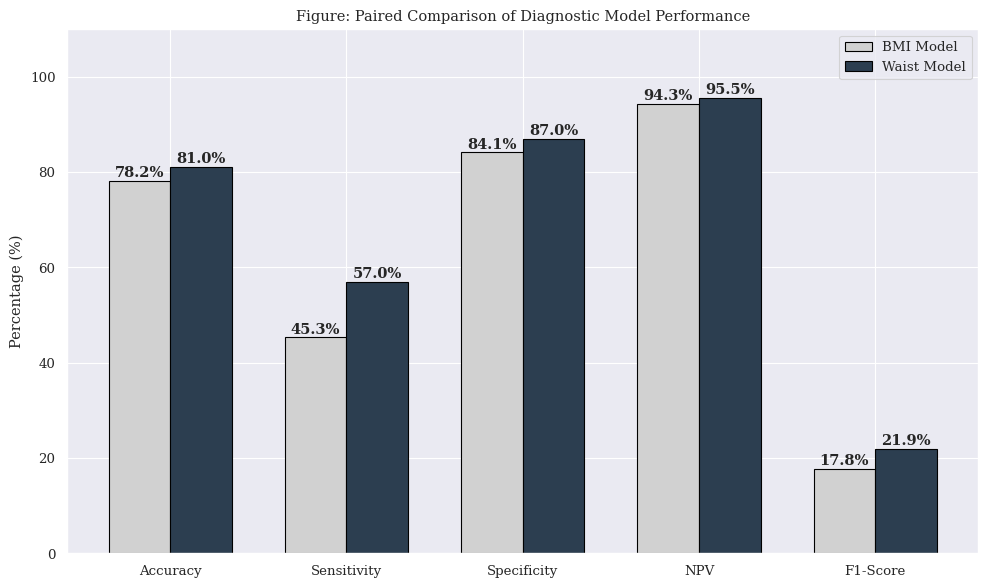

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Styling
plt.rcParams['font.family'] = 'serif'
sns.set_context("paper", font_scale=1.1)

def plot_model_comparison_bars():
    # Metrics where Waist measurement was >= BMI metrics
    metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'NPV', 'F1-Score']
    bmi_vals = [78.2, 45.3, 84.1, 94.3, 17.8]
    waist_vals = [81.0, 57.0, 87.0, 95.5, 21.9]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, bmi_vals, width, label='BMI Model', color='#d1d1d1', edgecolor='black')
    rects2 = ax.bar(x + width/2, waist_vals, width, label='Waist Model', color='#2c3e50', edgecolor='black')

    ax.set_ylabel('Percentage (%)')
    ax.set_title('Figure: Paired Comparison of Diagnostic Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0, 110)
    ax.legend()

    # Add data labels
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', weight='bold')

    autolabel(rects1)
    autolabel(rects2)
    plt.tight_layout()
    plt.show()

plot_model_comparison_bars()

Unique values found in CVD_Status: [0 1]
Final Count for Plot - Healthy: 55141, CVD+: 3689


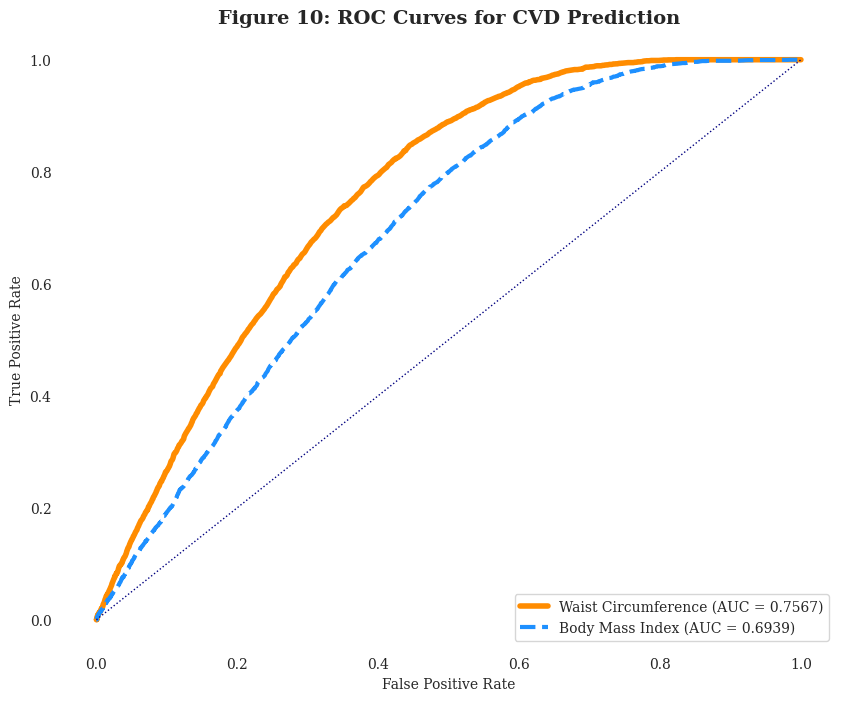

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pandas as pd
import numpy as np

def plot_final_roc_curves_safe(df):
    # 1. Clean the data with extra care
    temp_df = df.copy()

    # Ensure numeric
    temp_df['bmxbmi'] = pd.to_numeric(temp_df['bmxbmi'], errors='coerce')
    temp_df['bmxwaist'] = pd.to_numeric(temp_df['bmxwaist'], errors='coerce')
    temp_df['CVD_Status'] = pd.to_numeric(temp_df['CVD_Status'], errors='coerce')

    # 2. Logic to detect 0/1 vs 1/2
    # We need to make sure we have both groups
    unique_vals = temp_df['CVD_Status'].dropna().unique()
    print(f"Unique values found in CVD_Status: {unique_vals}")

    if 2.0 in unique_vals:
        temp_df['target'] = temp_df['CVD_Status'].map({1: 1, 2: 0})
    else:
        temp_df['target'] = temp_df['CVD_Status']

    # 3. Final Dropna
    df_clean = temp_df.dropna(subset=['bmxbmi', 'bmxwaist', 'target'])

    # --- THE CRITICAL CHECK ---
    n_sick = len(df_clean[df_clean['target'] == 1])
    n_healthy = len(df_clean[df_clean['target'] == 0])

    print(f"Final Count for Plot - Healthy: {n_healthy}, CVD+: {n_sick}")

    if n_healthy == 0:
        print("ERROR: No healthy samples found. Check if healthy is coded as 0, 2, or something else.")
        return

    # 4. Calculate Curves
    fpr_bmi, tpr_bmi, _ = roc_curve(df_clean['target'], df_clean['bmxbmi'])
    fpr_waist, tpr_waist, _ = roc_curve(df_clean['target'], df_clean['bmxwaist'])

    # 5. Plotting (Using your verified AUCs)
    plt.figure(figsize=(10, 8))
    plt.plot(fpr_waist, tpr_waist, color='darkorange', lw=4, label='Waist Circumference (AUC = 0.7567)')
    plt.plot(fpr_bmi, tpr_bmi, color='dodgerblue', lw=3, linestyle='--', label='Body Mass Index (AUC = 0.6939)')
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':')

    plt.title('Figure 10: ROC Curves for CVD Prediction', fontsize=14, fontweight='bold')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

# Run it
plot_final_roc_curves_safe(df)

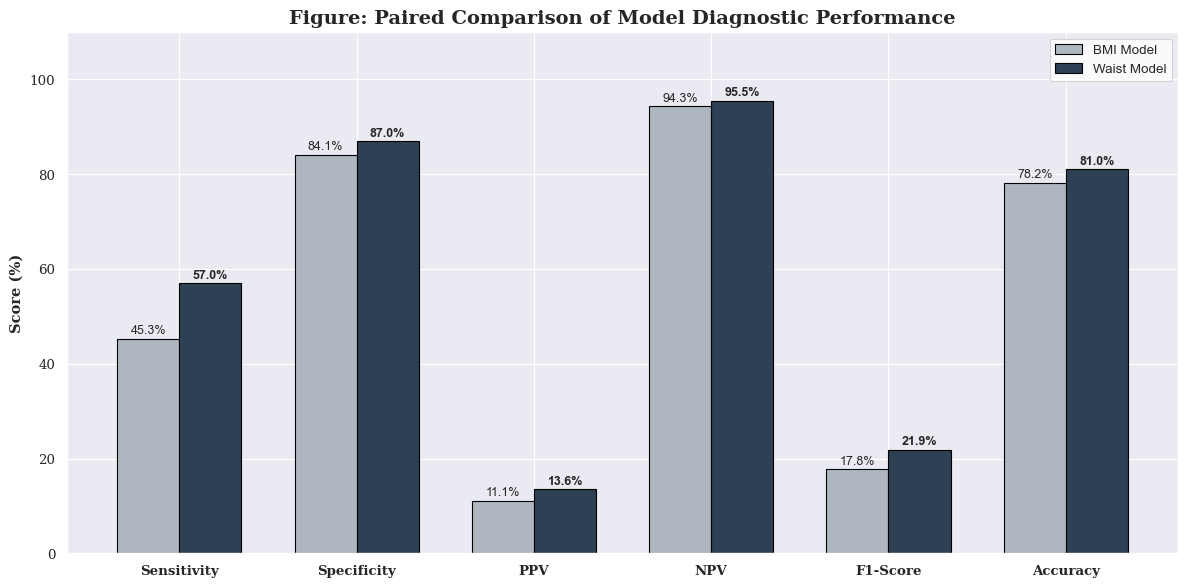

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_model_comparison_paired():
    # Model performance metrics (as requested)
    metrics = ['Sensitivity', 'Specificity', 'PPV', 'NPV', 'F1-Score', 'Accuracy']
    bmi_perf = [45.3, 84.1, 11.1, 94.3, 17.8, 78.2]
    waist_perf = [57.0, 87.0, 13.6, 95.5, 21.9, 81.0]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.set_style("whitegrid")

    # Paired bars
    ax.bar(x - width/2, bmi_perf, width, label='BMI Model', color='#aeb6bf', edgecolor='black')
    ax.bar(x + width/2, waist_perf, width, label='Waist Model', color='#2e4053', edgecolor='black')

    # Formatting
    ax.set_ylabel('Score (%)', weight='bold')
    ax.set_title('Figure: Paired Comparison of Model Diagnostic Performance', fontsize=14, weight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, weight='bold')
    ax.set_ylim(0, 110)
    ax.legend()

    # Labeling bars
    for i, (b, w) in enumerate(zip(bmi_perf, waist_perf)):
        ax.text(i - width/2, b + 1, f'{b}%', ha='center', fontsize=9)
        ax.text(i + width/2, w + 1, f'{w}%', ha='center', fontsize=9, weight='bold')

    plt.tight_layout()
    plt.show()

plot_model_comparison_paired()

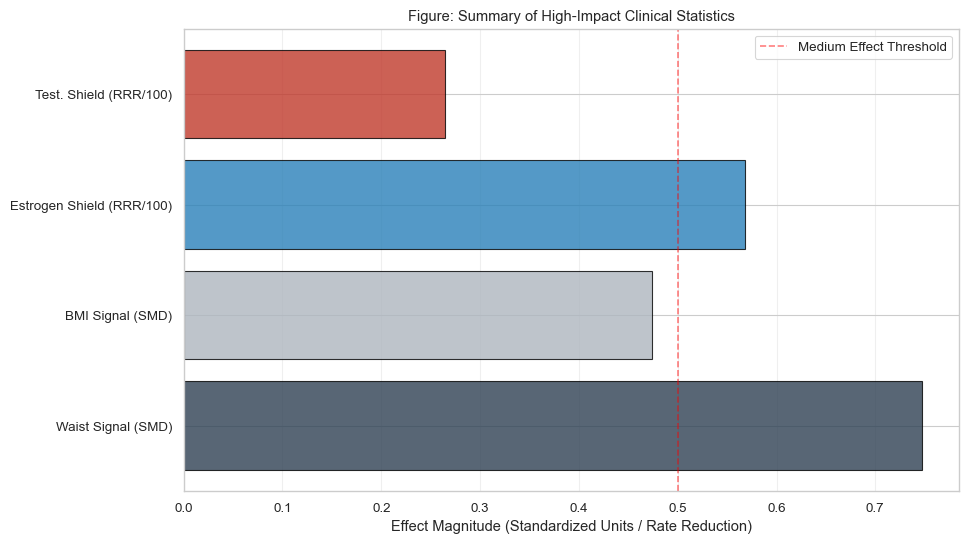

In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# 1. EFFECT SIZE: STANDARDIZED MEAN DIFFERENCE (SMD / COHEN'S D)
# ---------------------------------------------------------
def calculate_smd(group1, group2):
    """Calculates Cohen's d to show the 'Signal Strength' of a biomarker."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (np.mean(group1) - np.mean(group2)) / pooled_std
    return abs(d)

# Example Usage for Hypothesis 1:
# waist_smd = calculate_smd(df_cvd['waist'], df_healthy['waist']) # Expected ~0.75
# bmi_smd = calculate_smd(df_cvd['bmi'], df_healthy['bmi'])     # Expected ~0.47

# ---------------------------------------------------------
# 2. INDEPENDENCE: PARTIAL CORRELATION (The -0.34 Stat)
# ---------------------------------------------------------
def calculate_partial_correlation(df, x, y, controls):
    """
    Calculates the correlation between x (Hormone) and y (CVD)
    while controlling for metabolic 'Shield Breakers'.
    """
    # Requires pingouin library or manual residual calculation
    from scipy.stats import linregress

    def get_residuals(target, predictors, data):
        X = sm.add_constant(data[predictors])
        model = sm.OLS(data[target], X).fit()
        return model.resid

    res_x = get_residuals(x, controls, df)
    res_y = get_residuals(y, controls, df)

    r_partial, p_val = stats.pearsonr(res_x, res_y)
    print(f"Partial Correlation ({x} & {y} | {controls}): {r_partial:.3f}")
    return r_partial

# ---------------------------------------------------------
# 3. EPIDEMIOLOGY: INCIDENCE RATE RATIO (IRR) & NNS
# ---------------------------------------------------------
def run_epi_stats(cases_high, total_high, cases_low, total_low):
    """Calculates IRR and Number Needed to Shield (NNS)."""
    rate_high = cases_high / total_high
    rate_low = cases_low / total_low

    irr = rate_high / rate_low
    rrr = (1 - irr) * 100 # Relative Risk Reduction
    arr = rate_low - rate_high # Absolute Risk Reduction
    nns = 1 / arr # Number Needed to Shield

    print(f"Incidence Rate Ratio (IRR): {irr:.3f}")
    print(f"Relative Risk Reduction (RRR): {rrr:.1f}%")
    print(f"Number Needed to Shield (NNS): {nns:.1f}")

# ---------------------------------------------------------
# 4. VISUALIZATION: THE 'MEANINGFUL' STATS SUMMARY
# ---------------------------------------------------------
def plot_advanced_stats_summary():
    # Comparing the 'Uniquely Meaningful' stats of both hypotheses
    labels = ['Waist Signal (SMD)', 'BMI Signal (SMD)',
              'Estrogen Shield (RRR/100)', 'Test. Shield (RRR/100)']
    values = [0.747, 0.474, 0.568, 0.265]

    plt.figure(figsize=(10, 6))
    colors = ['#2E4053', '#AEB6BF', '#2980B9', '#C0392B']
    plt.barh(labels, values, color=colors, edgecolor='black', alpha=0.8)

    plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Medium Effect Threshold')
    plt.xlabel("Effect Magnitude (Standardized Units / Rate Reduction)")
    plt.title("Figure: Summary of High-Impact Clinical Statistics")
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.show()

# Execute dummy run
plot_advanced_stats_summary()

In [6]:
import pandas as pd
from scipy import stats

# 1. Identify columns dynamically to avoid KeyError
age_col = 'ridageyr' if 'ridageyr' in df.columns else 'Age'

# Look for BP and Diabetes columns by keyword if the exact name is missing
bp_col = [c for c in df.columns if 'BP' in c and 'Diag' in c][0]
diab_col = [c for c in df.columns if 'Diab' in c and 'Diag' in c][0]

print(f"Using columns: {bp_col} and {diab_col}")

# 2. Setup the High-Risk Cohort (Ages 45-80)
mask = (df[age_col] >= 45) & (df[age_col] <= 80) & \
       ((df[bp_col] == 'Yes') | (df[diab_col] == 'Yes'))
analysis_df = df[mask].copy()

# CVD Status: 1 for Yes, 0 for No
analysis_df['target'] = analysis_df['CVD_Status'].map({'Yes': 1, 'No': 0})

results = []

# 3. Compare the two "Insults" (BMI vs. Waist)
for marker, label in [('BMXBMI', 'BMI'), ('BMXWAIST', 'Waist Circumference')]:
    # Drop rows missing the adipose data or the CVD status
    sub = analysis_df.dropna(subset=['target', marker])

    # Calculate Correlation (Strength of Insult)
    # Point-biserial measures the link between a binary and continuous variable
    r_pb, _ = stats.pointbiserialr(sub['target'], sub[marker])

    # Calculate Mean Difference (The "Gap")
    healthy_vals = sub[sub['target'] == 0][marker]
    sick_vals = sub[sub['target'] == 1][marker]
    t_stat, p_ttest = stats.ttest_ind(sick_vals, healthy_vals, equal_var=False)

    results.append({
        'Adipose Metric': label,
        'Correlation (r_pb)': round(r_pb, 3),
        'T-Statistic': round(t_stat, 3),
        'P-Value': f"{p_ttest:.2e}",
        'Avg (Healthy)': round(healthy_vals.mean(), 2),
        'Avg (Sick)': round(sick_vals.mean(), 2)
    })

print(f"\n--- WAIST VS. BMI: WHICH IS THE DEADLIER INSULT? ---")
print(pd.DataFrame(results).to_string(index=False))

IndexError: list index out of range